## Settings

In [727]:
## auto reload modules
%reload_ext autoreload
%autoreload 2

## Dependencies

In [728]:
## libraries
import sys
from pathlib import Path

## path
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

## modules
from src.data.builders import load_processed_data
from src.estimators.factories import load_estimators

## constants
from src.evaluators.config import (
    FEAT_X,
    FEAT_Z,
    TARGET,
)

## Initialization

In [729]:
## reproducibility
N_DECIMALS   = 2
N_REPEATS    = 30
RANDOM_STATE = 42

## load data and models
data   = load_processed_data()
models = load_estimators(random_state = RANDOM_STATE)

## view data shape
n_obs, n_feat = data.shape
print(f"Original Data: {n_feat} features, {n_obs} observations")

## view model surface
n_mods = len(models)
print(f"Learned Models: {n_mods} estimators")

Original Data: 32 features, 25 observations
Learned Models: 9 estimators


## Universality of Network Capacity

Three converging lines of evidence establish that event capacity is a fundamental invariant of complex networks — not an artefact of measurement, modelling, or domain-specific context.

**Rows (resampling regimes):** Each row evaluates a generalization condition.
- *Domain LOGO*: One scientific domain (5 total) is withheld entirely from training; the frontier is evaluated on observations the model has never encountered at the domain level.
- *Discipline LOGO*: One scientific discipline (25 total) is withheld from training, the hardest group-out condition in the study.
- *Random 5-Fold / Random 10-Fold*: Shuffled split baselines used to contextualize whether held-out-group transfer materially degrades the frontier.

**Columns (learning paradigms):** Each column represents a methodologically distinct estimator family. Stability across columns demonstrates that the recovered ordering is not a consequence of any particular modelling choice.

**Panels:** Each panel shows the per-discipline median estimated frontier (`y`) against the per-discipline median observed capacity (`x`). Points are colored by scientific domain; the grey dashed diagonal is the locus of perfect frontier equality ($\hat{y} = y$). Points above the diagonal indicate a valid frontier (the estimated bound encloses observations); red `x` markers indicate constraint violations. Efficiency Index (`EI`) and Composite Index (`CI`) are annotated per panel and computed from all valid observations, not from the displayed median dots.

**What to look for:** (i) Tight scatter near the diagonal in every panel — the frontier is accurate. (ii) The scatter is stable across columns — the frontier is paradigm-robust. (iii) The held-out rows remain comparable to random-split baselines — the frontier transfers to unseen groups without material degradation. Together, these invariances establish that network event capacity is a universal structural law accessible to any sufficiently expressive learner.

In [730]:
## ═══════════════════════════════════════════════════════════════════════════
## LEGACY ALL-IN-ONE UNIVERSALITY CELL — DISABLED
##
## This older cell trained models and rendered the figure in one pass. It is
## intentionally disabled so visual edits do not trigger retraining.
##
## Use the workflow below instead:
##   1. Run the COMPUTE cell only when data, features, models, resampling
##      regimes, or RANDOM_STATE change, or when RECOMPUTE = True.
##   2. Edit and rerun the RENDER cell freely for visual changes. It loads
##      outputs/cache/universality_paradigm_preds.pkl when needed.
## ═══════════════════════════════════════════════════════════════════════════

print("Legacy universality training/render cell disabled. Use COMPUTE once, then rerun RENDER for visual edits.")


Legacy universality training/render cell disabled. Use COMPUTE once, then rerun RENDER for visual edits.


## Visualization Workflow
Run the **COMPUTE** cell only when the data, features, model set, resampling regimes, or `RANDOM_STATE` change. For ordinary plot tweaks, edit and rerun only the **RENDER ONLY** cell; it uses cached predictions from `outputs/cache/universality_paradigm_preds.pkl` and does not call the training pipeline.

In [731]:
## ═══════════════════════════════════════════════════════════════════════════
## UNIVERSALITY BY LEARNING PARADIGM AND RESAMPLING REGIME — COMPUTE
##
## Computes per-model OOF predictions across regimes and aggregates them
## into paradigm groups. Results are cached to disk so re-running this cell
## (or restarting the kernel) is near-instant after the first run, and the
## render cell below can be iterated on without retraining.
##
## For visual edits, skip this cell and rerun the RENDER cell below.
## To force recompute: set RECOMPUTE = True, or delete the cache file.
## ═══════════════════════════════════════════════════════════════════════════

import os
import pickle
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut, KFold
from sklearn.base import clone

from src.evaluators.training import fit_predict_frontier
from src.visualizers.visualizing import (
    DEFAULT_PARADIGM_ORDER,
    DEFAULT_MODEL_TO_PARADIGM,
)

## ─── cache control ──────────────────────────────────────────────────────────
RECOMPUTE  = False
CACHE_DIR  = "outputs/cache"
CACHE_PATH = os.path.join(CACHE_DIR, "universality_paradigm_preds.pkl")

## ─── resampling regimes ─────────────────────────────────────────────────────
REGIMES = [
    ("domain_logo", "Domain\nLOGO"),
    ("disc_logo",   "Discipline\nLOGO"),
    ("kfold_5",     "Random\n5-Fold"),
    ("kfold_10",    "Random\n10-Fold"),
]

## ─── paradigm groups ────────────────────────────────────────────────────────
PARADIGM_ORDER = list(DEFAULT_PARADIGM_ORDER)
PARADIGM_TO_MODELS = {p: [] for p in PARADIGM_ORDER}
for mn in models.keys():
    p = DEFAULT_MODEL_TO_PARADIGM.get(mn)
    if p is not None and p in PARADIGM_TO_MODELS:
        PARADIGM_TO_MODELS[p].append(mn)

## ─── load cache if present ──────────────────────────────────────────────────
viz_preds_par = {}
if not RECOMPUTE and os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "rb") as fh:
        cached = pickle.load(fh)
    if cached.get("n_obs") == len(data) and cached.get("random_state") == RANDOM_STATE:
        viz_preds_par = cached.get("viz_preds_par", {})
        print(f"Loaded cache: {len(viz_preds_par)} (model, regime) entries from {CACHE_PATH}")
    else:
        print("Cache invalid (data shape or random state changed); recomputing.")

## ─── OOF helpers ────────────────────────────────────────────────────────────
_n_rep = min(10, N_REPEATS)

def _logo_oof(grp_arr, mo):
    yp  = np.full(len(data), np.nan)
    loo = LeaveOneGroupOut()
    for tri, tei in loo.split(data, groups=grp_arr):
        tr  = data.iloc[tri].reset_index(drop=True)
        te  = data.iloc[tei].reset_index(drop=True)
        fit = fit_predict_frontier(
            data         = tr,
            feat_x       = FEAT_X,
            feat_z       = FEAT_Z,
            estimator_c  = clone(mo.estimator_c),
            estimator_r  = clone(mo.estimator_r),
            target       = TARGET,
            n_repeat     = _n_rep,
            random_state = RANDOM_STATE,
        )
        yp[tei] = fit_predict_frontier(data=te, fit_result=fit)["y_pred"]
    return yp

def _kfold_oof(n_splits, mo):
    yp = np.full(len(data), np.nan)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for tri, tei in kf.split(data):
        tr  = data.iloc[tri].reset_index(drop=True)
        te  = data.iloc[tei].reset_index(drop=True)
        fit = fit_predict_frontier(
            data         = tr,
            feat_x       = FEAT_X,
            feat_z       = FEAT_Z,
            estimator_c  = clone(mo.estimator_c),
            estimator_r  = clone(mo.estimator_r),
            target       = TARGET,
            n_repeat     = _n_rep,
            random_state = RANDOM_STATE,
        )
        yp[tei] = fit_predict_frontier(data=te, fit_result=fit)["y_pred"]
    return yp

dom_arr_full  = data["domain"].to_numpy()
disc_arr_full = data["discipline"].to_numpy()

## ─── compute only what's missing from the cache ─────────────────────────────
needed_keys = [(mn, rk) for mn in models.keys() for rk, _ in REGIMES]
missing     = [k for k in needed_keys if k not in viz_preds_par]

if missing:
    print(f"Computing {len(missing)} missing (model, regime) entries...")
    for mn, mo in models.items():
        todo = [rk for rk, _ in REGIMES if (mn, rk) not in viz_preds_par]
        if not todo:
            continue
        print(f"  {mn}: {todo}", flush=True)
        for rk in todo:
            if rk == "domain_logo":
                ## reuse cached domain LOGO from prior cell if available
                if "viz_preds" in globals() and (mn, "domain_logo") in viz_preds:
                    viz_preds_par[(mn, rk)] = viz_preds[(mn, "domain_logo")]
                else:
                    viz_preds_par[(mn, rk)] = _logo_oof(dom_arr_full, mo)
            elif rk == "disc_logo":
                if "viz_preds" in globals() and (mn, "disc_logo") in viz_preds:
                    viz_preds_par[(mn, rk)] = viz_preds[(mn, "disc_logo")]
                else:
                    viz_preds_par[(mn, rk)] = _logo_oof(disc_arr_full, mo)
            elif rk == "kfold_5":
                viz_preds_par[(mn, rk)] = _kfold_oof(5, mo)
            elif rk == "kfold_10":
                viz_preds_par[(mn, rk)] = _kfold_oof(10, mo)

    os.makedirs(CACHE_DIR, exist_ok=True)
    with open(CACHE_PATH, "wb") as fh:
        pickle.dump(
            dict(
                viz_preds_par = viz_preds_par,
                n_obs         = len(data),
                random_state  = RANDOM_STATE,
                regimes       = REGIMES,
                paradigm_order = PARADIGM_ORDER,
                paradigm_to_models = PARADIGM_TO_MODELS,
            ),
            fh,
        )
    print(f"Saved cache → {CACHE_PATH}")
else:
    print("All (model, regime) entries available; no computation needed.")

## ─── aggregate base learners → paradigm via per-observation median ──────────
viz_preds_par_agg = {}            ## (paradigm, regime) -> y_pred array
for p in PARADIGM_ORDER:
    member_models = PARADIGM_TO_MODELS[p]
    for rkey, _ in REGIMES:
        stacked = np.vstack([viz_preds_par[(m, rkey)] for m in member_models])
        viz_preds_par_agg[(p, rkey)] = np.nanmedian(stacked, axis=0)

print("Done.")

Loaded cache: 36 (model, regime) entries from outputs/cache/universality_paradigm_preds.pkl
All (model, regime) entries available; no computation needed.
Done.


Using in-memory cached predictions; render-only cell will not retrain.
2026-05-15 23:13:43,153 - INFO - maxp pruned
2026-05-15 23:13:43,156 - INFO - cmap pruned
2026-05-15 23:13:43,157 - INFO - kern dropped
2026-05-15 23:13:43,157 - INFO - post pruned
2026-05-15 23:13:43,157 - INFO - FFTM dropped
2026-05-15 23:13:43,159 - INFO - GPOS pruned
2026-05-15 23:13:43,160 - INFO - GSUB pruned
2026-05-15 23:13:43,162 - INFO - glyf pruned
2026-05-15 23:13:43,163 - INFO - Added gid0 to subset
2026-05-15 23:13:43,163 - INFO - Added first four glyphs to subset
2026-05-15 23:13:43,163 - INFO - Closing glyph list over 'GSUB': 53 glyphs before
2026-05-15 23:13:43,164 - INFO - Glyph names: ['.notdef', '.null', 'C', 'D', 'E', 'F', 'G', 'I', 'L', 'M', 'N', 'O', 'R', 'S', 'U', 'a', 'b', 'c', 'comma', 'd', 'e', 'eight', 'equal', 'five', 'four', 'g', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', '

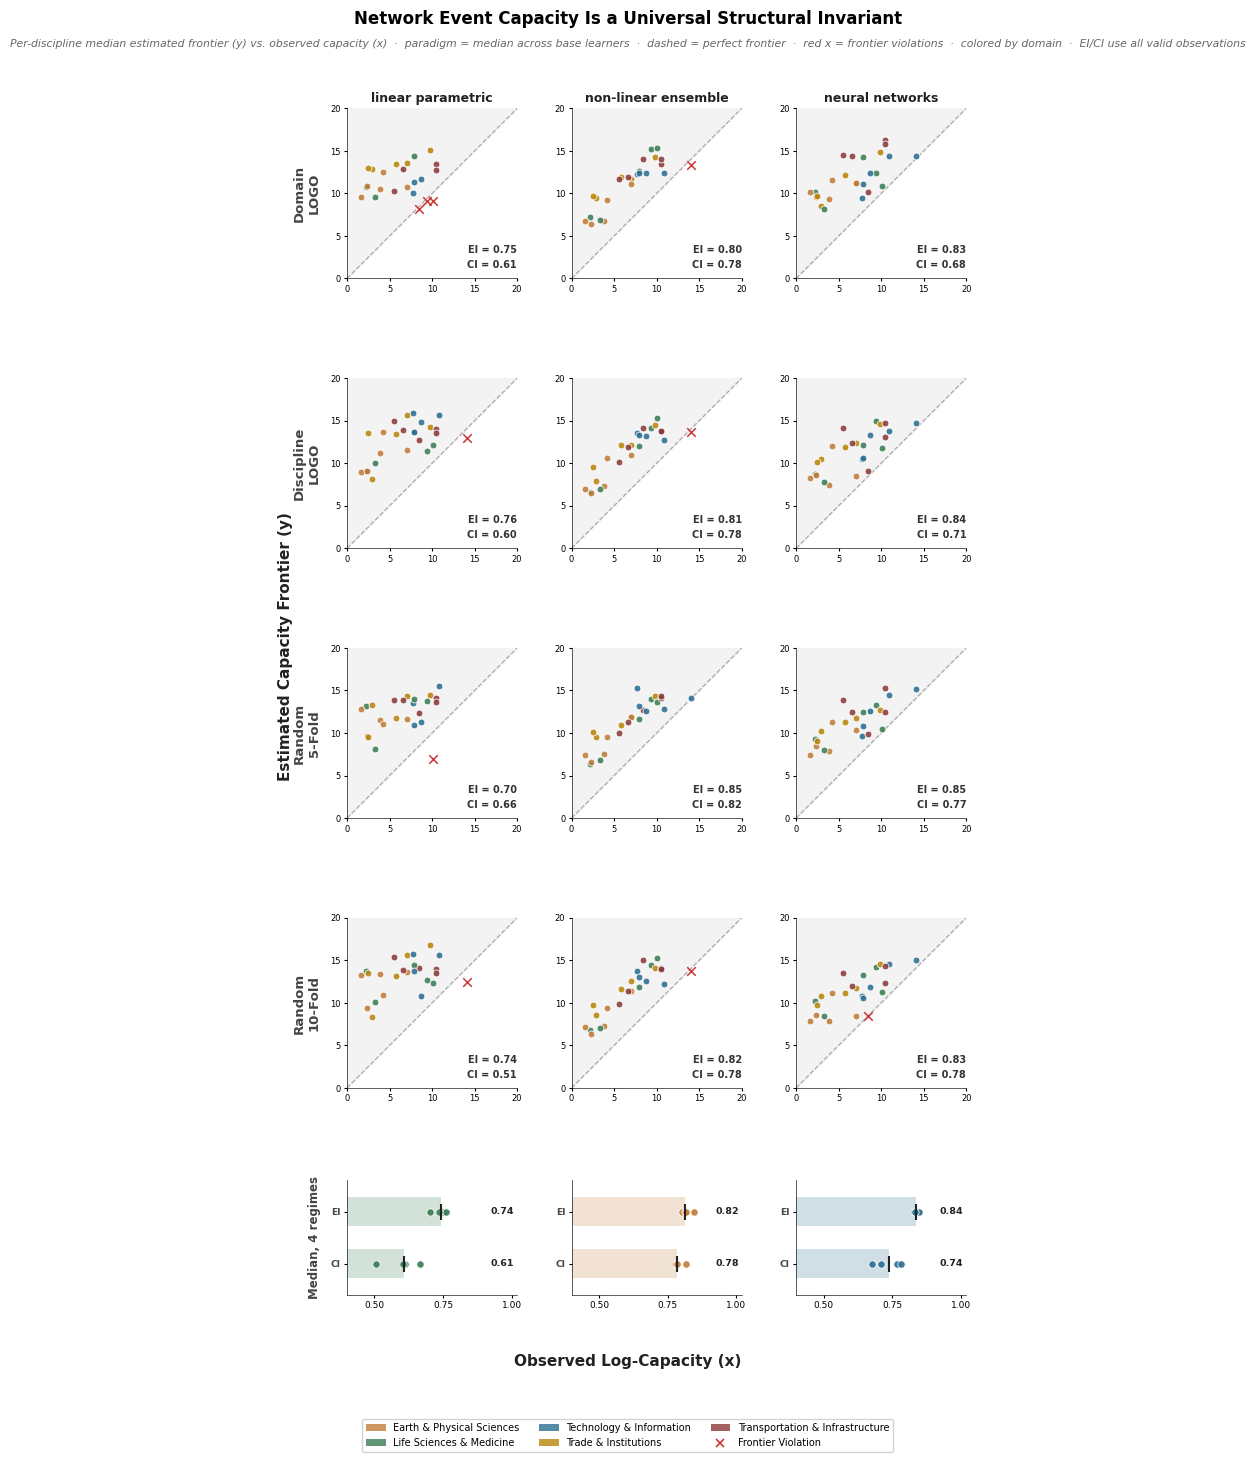

In [732]:
## ═══════════════════════════════════════════════════════════════════════════
## UNIVERSALITY BY LEARNING PARADIGM AND RESAMPLING REGIME — RENDER ONLY
##
## Pure visualization. Edit and rerun this cell freely for layout, labeling,
## colors, annotations, marker styling, or export settings. It never trains.
## If `viz_preds_par_agg` is not already in memory, it loads cached predictions
## from outputs/cache/universality_paradigm_preds.pkl and aggregates them.
## ═══════════════════════════════════════════════════════════════════════════

import os
import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from src.evaluators.metrics import _efficiency_index, consensus_metrics
from src.vectorizers.scalers import _log_transformer
from src.visualizers.visualizing import (
    DEFAULT_PARADIGM_ORDER,
    DEFAULT_MODEL_TO_PARADIGM,
)

## ─── cache-backed prediction loading ────────────────────────────────────────
CACHE_DIR = "outputs/cache"
CACHE_PATH = os.path.join(CACHE_DIR, "universality_paradigm_preds.pkl")

REGIMES = [
    ("domain_logo", "Domain\nLOGO"),
    ("disc_logo",   "Discipline\nLOGO"),
    ("kfold_5",     "Random\n5-Fold"),
    ("kfold_10",    "Random\n10-Fold"),
]
PARADIGM_ORDER = list(DEFAULT_PARADIGM_ORDER)
PARADIGM_TO_MODELS = {p: [] for p in PARADIGM_ORDER}
for mn in models.keys():
    paradigm = DEFAULT_MODEL_TO_PARADIGM.get(mn)
    if paradigm is not None and paradigm in PARADIGM_TO_MODELS:
        PARADIGM_TO_MODELS[paradigm].append(mn)

if "viz_preds_par_agg" not in globals():
    if not os.path.exists(CACHE_PATH):
        raise FileNotFoundError(
            f"Cached predictions not found at {CACHE_PATH}. "
            "Run the COMPUTE cell once, then rerun this render cell."
        )
    with open(CACHE_PATH, "rb") as fh:
        cached = pickle.load(fh)
    if cached.get("n_obs") != len(data) or cached.get("random_state") != RANDOM_STATE:
        raise RuntimeError(
            "Cached predictions were produced for a different data shape or RANDOM_STATE. "
            "Rerun the COMPUTE cell with RECOMPUTE = True."
        )

    viz_preds_par = cached.get("viz_preds_par", {})
    missing_keys = [
        (model_name, regime_key)
        for model_name in models.keys()
        for regime_key, _ in REGIMES
        if (model_name, regime_key) not in viz_preds_par
    ]
    if missing_keys:
        preview = missing_keys[:5]
        raise RuntimeError(
            f"Cached predictions are missing {len(missing_keys)} model/regime entries; "
            f"examples: {preview}. Rerun the COMPUTE cell."
        )

    viz_preds_par_agg = {}
    for paradigm in PARADIGM_ORDER:
        member_models = PARADIGM_TO_MODELS[paradigm]
        if not member_models:
            continue
        for regime_key, _ in REGIMES:
            stacked = np.vstack([viz_preds_par[(model_name, regime_key)] for model_name in member_models])
            viz_preds_par_agg[(paradigm, regime_key)] = np.nanmedian(stacked, axis = 0)
    print(f"Loaded cached predictions from {CACHE_PATH}; render-only cell will not retrain.")
else:
    print("Using in-memory cached predictions; render-only cell will not retrain.")

## ─── domain palette ──────────────────────────────────────────────────────────
DOMAIN_PALETTE = {
    "Earth & Physical Sciences":       "#C07D3A",
    "Life Sciences & Medicine":        "#3A7D55",
    "Technology & Information":        "#2C6E91",
    "Trade & Institutions":            "#B8860B",
    "Transportation & Infrastructure": "#8B3A3A",
}

_par_palette = {
    "linear parametric":   "#3A7D55",
    "non-linear ensemble": "#C07D3A",
    "neural networks":     "#2C6E91",
}

## ─── figure geometry ─────────────────────────────────────────────────────────
##   Per-row inch factor is tuned so each scatter panel (aspect = equal,
##   adjustable = box) renders square at the FULL gridspec column width. That
##   in turn forces the bottom summary panels (no aspect constraint) to render
##   at the exact same column width — column-wise alignment between the
##   scatter grid and the summary strip falls out of the gridspec geometry.
n_col = len(PARADIGM_ORDER)
n_row = len(REGIMES)
SUMMARY_ROW_RATIO = 0.62

fig, axes = plt.subplots(
    n_row + 1, n_col,
    figsize     = (n_col * 2.40, (n_row + SUMMARY_ROW_RATIO) * 2.80 + 1.80),
    gridspec_kw = dict(
        height_ratios = [1.0] * n_row + [SUMMARY_ROW_RATIO],
        hspace        = 0.50,
        wspace        = 0.32,
    ),
    squeeze = False,
)
fig.subplots_adjust(top = 0.92, left = 0.11, right = 0.97, bottom = 0.11)

## ─── super-title + subtitle ──────────────────────────────────────────────────
fig.text(
    0.50, 0.982,
    "Network Event Capacity Is a Universal Structural Invariant",
    ha = "center", va = "top",
    fontsize = 12, fontweight = "bold",
    transform = fig.transFigure,
)
fig.text(
    0.50, 0.962,
    "Per-discipline median estimated frontier (y) vs. observed capacity (x)  ·  "
    "paradigm = median across base learners  ·  "
    "dashed = perfect frontier  ·  red x = frontier violations  ·  colored by domain  ·  "
    "EI/CI use all valid observations",
    ha = "center", va = "top",
    fontsize = 7.8, color = "#666", fontstyle = "italic",
    transform = fig.transFigure,
)

## ─── per-observation arrays ──────────────────────────────────────────────────
y_log    = _log_transformer(data[TARGET]).to_numpy(dtype = float)
dom_arr  = data["domain"].to_numpy()
disc_arr = data["discipline"].to_numpy()
discs    = np.unique(disc_arr)

## ─── precompute per-panel discipline-median points ──────────────────────────
panel_points = {}    ## (regime, paradigm) -> (xt_d, xp_d, clr_d)
for regime_key, _ in REGIMES:
    for paradigm in PARADIGM_ORDER:
        yp = viz_preds_par_agg[(paradigm, regime_key)]
        vm = np.isfinite(y_log) & np.isfinite(yp)

        xt_d, xp_d, clr_d = [], [], []
        for disc in discs:
            dm = (disc_arr == disc) & vm
            if not dm.any():
                continue
            xt_d.append(np.median(y_log[dm]))
            xp_d.append(np.median(yp[dm]))
            clr_d.append(DOMAIN_PALETTE.get(dom_arr[dm][0], "#888888"))

        panel_points[(regime_key, paradigm)] = (
            np.array(xt_d, dtype = float),
            np.array(xp_d, dtype = float),
            clr_d,
        )

SHARED_XL = 0.0
SHARED_XH = 20.0
SHARED_TICKS = np.linspace(SHARED_XL, SHARED_XH, 5)

## ─── scatter panel loop ──────────────────────────────────────────────────────
panel_metrics = {}    ## (regime, paradigm) -> {"ei": float, "ci": float}

for row_index, (regime_key, regime_label) in enumerate(REGIMES):
    for column_index, paradigm in enumerate(PARADIGM_ORDER):
        axis = axes[row_index, column_index]
        yp = viz_preds_par_agg[(paradigm, regime_key)]

        vm = np.isfinite(y_log) & np.isfinite(yp)
        xt_f = y_log[vm]
        xp_f = yp[vm]

        ei = _efficiency_index(y_true = xt_f, y_pred = xp_f)
        capacity_ci = consensus_metrics(y_true = xt_f, y_pred = xp_f)["ci"]
        panel_metrics[(regime_key, paradigm)] = {"ei": ei, "ci": capacity_ci}

        xt_d, xp_d, clr_d = panel_points[(regime_key, paradigm)]
        viol = xp_d < xt_d

        axis.set_xlim(SHARED_XL, SHARED_XH)
        axis.set_ylim(SHARED_XL, SHARED_XH)
        axis.set_xticks(SHARED_TICKS)
        axis.set_yticks(SHARED_TICKS)

        xx = np.array([SHARED_XL, SHARED_XH])
        axis.fill_between(xx, xx, SHARED_XH, color = "#F3F3F3", zorder = 0, clip_on = True)
        axis.plot(xx, xx, color = "#AAAAAA", lw = 0.9, ls = "--", zorder = 1)

        for point_index in range(len(xt_d)):
            if viol[point_index]:
                axis.scatter(
                    xt_d[point_index], xp_d[point_index],
                    marker = "x",
                    c = "#CC3333",
                    s = 38,
                    alpha = 0.95,
                    linewidths = 1.15,
                    zorder = 5,
                )
            else:
                axis.scatter(
                    xt_d[point_index], xp_d[point_index],
                    marker = "o",
                    c = clr_d[point_index],
                    s = 24,
                    alpha = 0.88,
                    linewidths = 0.65,
                    edgecolors = "white",
                    zorder = 4,
                )

        ## right-edge of label flush with right spine = highest x-axis point
        axis.text(
            1.0, 0.05,
            f"EI = {ei:.2f}\nCI = {capacity_ci:.2f}",
            transform = axis.transAxes,
            ha = "right", va = "bottom",
            fontsize = 7.0,
            fontweight = "semibold",
            color = "#333333",
            linespacing = 1.6,
        )

        axis.set_aspect("equal", adjustable = "box")
        axis.spines[["top", "right"]].set_visible(False)
        axis.spines[["bottom", "left"]].set_linewidth(0.45)
        axis.tick_params(labelsize = 6.0, pad = 2, length = 2.5)

        if row_index == 0:
            axis.set_title(
                paradigm,
                fontsize = 9.0,
                fontweight = "semibold",
                pad = 5,
                color = "#222222",
            )

    axes[row_index, 0].set_ylabel(
        regime_label,
        fontsize = 9.5,
        fontweight = "semibold",
        color = "#444444",
        labelpad = 7,
    )

## ─── paradigm-wise summary strip (bottom row) ───────────────────────────────
##   one panel per paradigm column. Two lanes per panel: EI on top, CI below.
##   Bar = median across the four resampling regimes.
##   Dots overlaid = per-regime values. Tight clustering of dots = the
##   paradigm's frontier quality is universal w.r.t. how the data are split.
SUMMARY_XLIM = (0.40, 1.02)

for column_index, paradigm in enumerate(PARADIGM_ORDER):
    summary_axis = axes[n_row, column_index]
    color = _par_palette[paradigm]

    ei_vals = np.array([panel_metrics[(rk, paradigm)]["ei"] for rk, _ in REGIMES])
    ci_vals = np.array([panel_metrics[(rk, paradigm)]["ci"] for rk, _ in REGIMES])
    median_ei = float(np.median(ei_vals))
    median_ci = float(np.median(ci_vals))

    ## faint median bars
    summary_axis.barh(
        [1, 0], [median_ei, median_ci],
        color  = color,
        alpha  = 0.22,
        height = 0.55,
        zorder = 2,
    )

    ## per-regime dots: the universality evidence
    for value in ei_vals:
        summary_axis.scatter(
            value, 1,
            c = color, s = 28, alpha = 0.92,
            edgecolors = "white", linewidths = 0.6, zorder = 4,
        )
    for value in ci_vals:
        summary_axis.scatter(
            value, 0,
            c = color, s = 28, alpha = 0.92,
            edgecolors = "white", linewidths = 0.6, zorder = 4,
        )

    ## median tick markers
    summary_axis.scatter(
        [median_ei, median_ci], [1, 0],
        marker = "|", c = "#222222", s = 130, lw = 1.5, zorder = 5,
    )

    ## numeric median annotation, right-aligned inside panel
    summary_axis.text(
        SUMMARY_XLIM[1] - 0.01, 1,
        f"{median_ei:.2f}",
        ha = "right", va = "center",
        fontsize = 6.8, fontweight = "semibold", color = "#222222",
    )
    summary_axis.text(
        SUMMARY_XLIM[1] - 0.01, 0,
        f"{median_ci:.2f}",
        ha = "right", va = "center",
        fontsize = 6.8, fontweight = "semibold", color = "#222222",
    )

    summary_axis.set_xlim(*SUMMARY_XLIM)
    summary_axis.set_ylim(-0.6, 1.6)
    summary_axis.set_yticks([1, 0])
    summary_axis.set_yticklabels(
        ["EI", "CI"],
        fontsize = 8.0, fontweight = "semibold", color = "#444444",
    )
    summary_axis.set_xticks([0.5, 0.75, 1.0])
    summary_axis.spines[["top", "right"]].set_visible(False)
    summary_axis.spines[["bottom", "left"]].set_linewidth(0.45)
    summary_axis.tick_params(labelsize = 6.5, pad = 2, length = 2.5)

axes[n_row, 0].set_ylabel(
    "Median, 4 regimes",
    fontsize = 8.5,
    fontweight = "semibold",
    color = "#444444",
    labelpad = 7,
)

## ─── shared axis labels ──────────────────────────────────────────────────────
fig.text(
    0.50, 0.060,
    "Observed Log-Capacity (x)",
    ha = "center", va = "bottom",
    fontsize = 11, fontweight = "semibold", color = "#222222",
)
fig.text(
    0.025, 0.55,
    "Estimated Capacity Frontier (y)",
    ha = "center", va = "center",
    fontsize = 11, fontweight = "semibold", rotation = 90, color = "#222222",
)

## ─── domain legend + violation key ──────────────────────────────────────────
leg_handles = [
    mpatches.Patch(facecolor = c, label = d, alpha = 0.80)
    for d, c in DOMAIN_PALETTE.items()
] + [
    Line2D(
        [], [], color = "#CC3333",
        marker = "x", linestyle = "None",
        markersize = 6.0, markeredgewidth = 1.2,
        label = "Frontier Violation",
    ),
]
fig.legend(
    handles        = leg_handles,
    loc            = "lower center",
    ncol           = 3,
    fontsize       = 7.0,
    framealpha     = 0.92,
    edgecolor      = "#D0D0D0",
    bbox_to_anchor = (0.50, 0.000),
)

## ─── save ────────────────────────────────────────────────────────────────────
os.makedirs("outputs/figures", exist_ok = True)
fig.savefig("outputs/figures/universality_paradigm.pdf", dpi = 300, bbox_inches = "tight")
fig.savefig("outputs/figures/universality_paradigm.png", dpi = 200, bbox_inches = "tight")
plt.show()

2026-05-15 23:13:45,192 - INFO - maxp pruned
2026-05-15 23:13:45,192 - INFO - LTSH dropped
2026-05-15 23:13:45,192 - INFO - cmap pruned
2026-05-15 23:13:45,192 - INFO - kern dropped
2026-05-15 23:13:45,194 - INFO - post pruned
2026-05-15 23:13:45,194 - INFO - PCLT dropped
2026-05-15 23:13:45,194 - INFO - JSTF dropped
2026-05-15 23:13:45,195 - INFO - DSIG dropped
2026-05-15 23:13:45,196 - INFO - GPOS pruned
2026-05-15 23:13:45,196 - INFO - GSUB pruned
2026-05-15 23:13:45,198 - INFO - glyf pruned
2026-05-15 23:13:45,199 - INFO - Added gid0 to subset
2026-05-15 23:13:45,199 - INFO - Added first four glyphs to subset
2026-05-15 23:13:45,200 - INFO - Closing glyph list over 'GSUB': 45 glyphs before
2026-05-15 23:13:45,200 - INFO - Glyph names: ['.notdef', '.null', 'C', 'E', 'I', 'L', 'M', 'P', 'S', 'T', 'a', 'ampersand', 'b', 'c', 'd', 'e', 'eight', 'equal', 'f', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'plus', 'r', 's', 'seven',

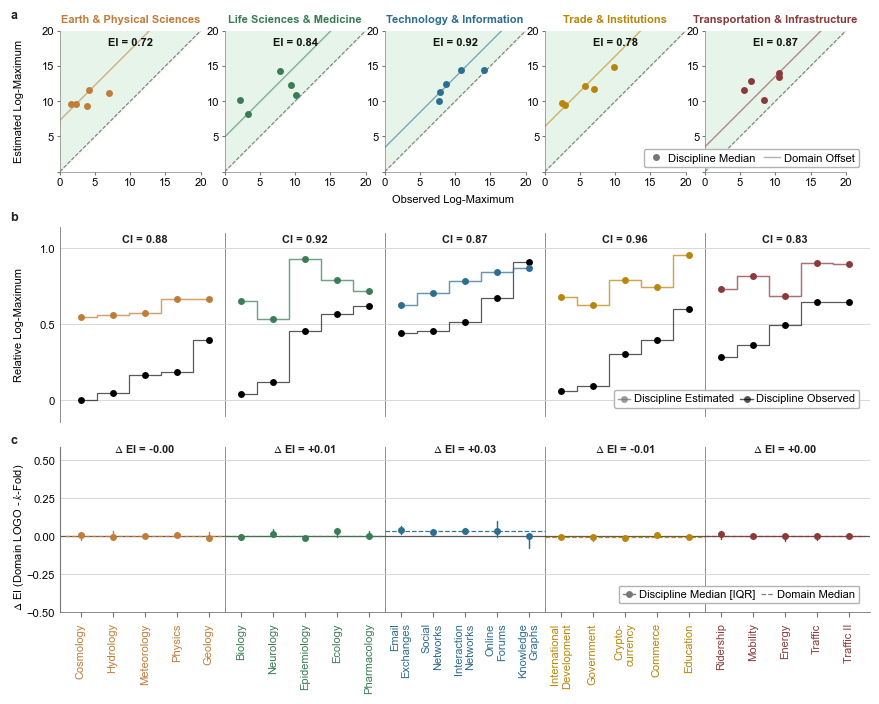

Data source: cached structure/transfer results
Saved superfigure to: /Users/nickkunz/Documents/Nick’s MacBook Pro/Python/graph-capacity/outputs/figures/universality_superfigure.png


In [733]:
## universality superfigure render -- source-backed
from pathlib import Path

import matplotlib.pyplot as plt

from src.visualizers.superfigure import plot_universality_superfigure

notebook_dir = Path.cwd().resolve()
project_root = root if "root" in globals() else notebook_dir.parent
out_dir = project_root / "outputs" / "figures"
out_dir.mkdir(parents = True, exist_ok = True)
root_cache_dir = project_root / "outputs" / "cache"
notebook_cache_dir = notebook_dir / "outputs" / "cache"
root_cache_dir.mkdir(parents = True, exist_ok = True)
notebook_cache_dir.mkdir(parents = True, exist_ok = True)

universality_cache_path = root_cache_dir / "universality_paradigm_preds.pkl"
if not universality_cache_path.exists():
    universality_cache_path = notebook_cache_dir / "universality_paradigm_preds.pkl"

transfer_structure_cache_path = root_cache_dir / "transfer_structure_results.pkl"
if not transfer_structure_cache_path.exists():
    transfer_structure_cache_path = notebook_cache_dir / "transfer_structure_results.pkl"

fig, axes, source_label = plot_universality_superfigure(
    data = data,
    models = models,
    feat_x = FEAT_X,
    feat_z = FEAT_Z,
    target = TARGET,
    random_state = RANDOM_STATE,
    n_repeats = N_REPEATS,
    universality_cache_path = universality_cache_path,
    transfer_structure_cache_path = transfer_structure_cache_path,
    force_recompute = False,
    show = False,
)

png_path = out_dir / "universality_superfigure.png"
pdf_path = out_dir / "universality_superfigure.pdf"
fig.savefig(
    fname = png_path,
    dpi = 300,
    facecolor = fig.get_facecolor(),
    bbox_inches = "tight",
)
fig.savefig(
    fname = pdf_path,
    dpi = 300,
    facecolor = fig.get_facecolor(),
    bbox_inches = "tight",
)
plt.show()

print(f"Data source: {source_label}")
print(f"Saved superfigure to: {png_path}")

## (markdown cell — text not recoverable)
<!-- This short markdown section-header cell was lost when an erroneous `git checkout` reverted the notebook; markdown/empty cells are not stored in the IPython execution history. Replace this with your original heading. All code cells were restored verbatim from history.sqlite session 1941. -->

## (markdown cell — text not recoverable)
<!-- This short markdown section-header cell was lost when an erroneous `git checkout` reverted the notebook; markdown/empty cells are not stored in the IPython execution history. Replace this with your original heading. All code cells were restored verbatim from history.sqlite session 1941. -->

2026-05-15 23:13:45,803 - INFO - maxp pruned
2026-05-15 23:13:45,807 - INFO - cmap pruned
2026-05-15 23:13:45,807 - INFO - kern dropped
2026-05-15 23:13:45,808 - INFO - post pruned
2026-05-15 23:13:45,808 - INFO - FFTM dropped
2026-05-15 23:13:45,809 - INFO - GPOS pruned
2026-05-15 23:13:45,810 - INFO - GSUB pruned
2026-05-15 23:13:45,813 - INFO - glyf pruned
2026-05-15 23:13:45,813 - INFO - Added gid0 to subset
2026-05-15 23:13:45,814 - INFO - Added first four glyphs to subset
2026-05-15 23:13:45,814 - INFO - Closing glyph list over 'MATH': 31 glyphs before
2026-05-15 23:13:45,814 - INFO - Glyph names: ['.notdef', '.null', 'N', 'S', 'a', 'b', 'c', 'colon', 'd', 'e', 'f', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'p', 'period', 'r', 's', 'space', 't', 'three', 'u', 'v', 'x', 'y']
2026-05-15 23:13:45,815 - INFO - Glyph IDs:   [0, 1, 2, 3, 16, 17, 22, 29, 49, 54, 68, 69, 70, 71, 72, 73, 74, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 91, 92]
2026-05-15 23:13:45

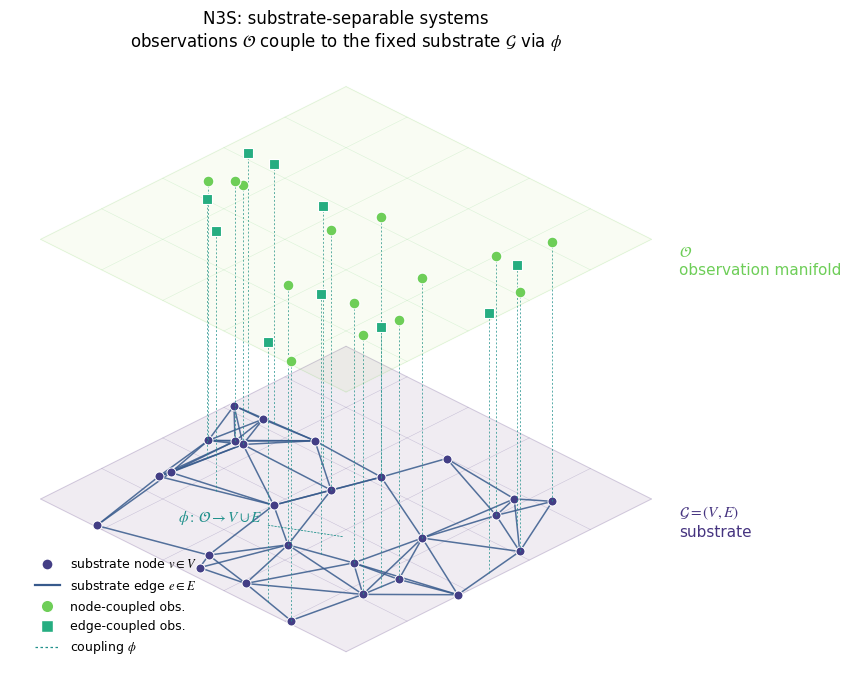

In [734]:
## n3s conceptual figure: substrate + observation manifold with coupling tethers
## reproducible, vectorizable, notebook-ready

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl

## ---------- reproducibility & style ----------
rng = np.random.default_rng(seed = 7)
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.linewidth": 0.6,
    "mathtext.fontset": "stix",
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

## ---------- isometric projection ----------
def iso(x, y, z):
    return (x - y), (0.5 * (x + y) + z)

## ---------- substrate: random geometric graph G(n, r) ----------
n = 28
pts = rng.uniform(0.0, 1.0, size = (n, 2))
r_c = np.sqrt(np.log(n) / (np.pi * n)) * 1.55
d = np.sqrt(((pts[:, None, :] - pts[None, :, :]) ** 2).sum(axis = -1))
adj = (d < r_c) & (d > 0)
edges = [(i, j) for i in range(n) for j in range(i + 1, n) if adj[i, j]]

## ---------- keep only nodes that participate in at least one edge ----------
## isolated nodes have no tether anchor for edge-coupled obs and look orphaned
node_degree = np.zeros(n, dtype = int)
for i, j in edges:
    node_degree[i] += 1
    node_degree[j] += 1
connected_nodes = np.where(node_degree > 0)[0]

## ---------- observation manifold ----------
h = 0.85

## node-coupled obs: only on nodes with degree >= 1 (guaranteed substrate anchor)
node_obs_idx = rng.choice(connected_nodes,
                          size = min(14, len(connected_nodes)),
                          replace = False)

## edge-coupled obs: sample edges directly (every edge is a valid anchor)
edge_obs_idx = rng.choice(len(edges),
                          size = min(10, len(edges)),
                          replace = False)

## ---------- viridis palette assignments ----------
cmap = plt.cm.viridis
c_substrate_node = cmap(0.18)
c_substrate_edge = cmap(0.28)
c_obs_node       = cmap(0.78)
c_obs_edge       = cmap(0.62)
c_tether         = cmap(0.50)

## ---------- figure setup ----------
fig, ax = plt.subplots(figsize = (9.0, 7.0))
ax.set_aspect("equal")
ax.axis("off")

## ---------- substrate plane ----------
plane_corners = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
sub_plane = np.array([iso(p[0], p[1], 0.0) for p in plane_corners])
ax.fill(sub_plane[:, 0], sub_plane[:, 1],
        color = cmap(0.05), alpha = 0.08, zorder = 0)
for t in np.linspace(0, 1, 6):
    a = iso(t, 0, 0); b = iso(t, 1, 0)
    ax.plot([a[0], b[0]], [a[1], b[1]],
            color = cmap(0.15), lw = 0.35, alpha = 0.25, zorder = 0)
    a = iso(0, t, 0); b = iso(1, t, 0)
    ax.plot([a[0], b[0]], [a[1], b[1]],
            color = cmap(0.15), lw = 0.35, alpha = 0.25, zorder = 0)

## ---------- observation plane ----------
obs_plane = np.array([iso(p[0], p[1], h) for p in plane_corners])
ax.fill(obs_plane[:, 0], obs_plane[:, 1],
        color = cmap(0.85), alpha = 0.06, zorder = 6)
for t in np.linspace(0, 1, 6):
    a = iso(t, 0, h); b = iso(t, 1, h)
    ax.plot([a[0], b[0]], [a[1], b[1]],
            color = cmap(0.75), lw = 0.35, alpha = 0.22, zorder = 6)
    a = iso(0, t, h); b = iso(1, t, h)
    ax.plot([a[0], b[0]], [a[1], b[1]],
            color = cmap(0.75), lw = 0.35, alpha = 0.22, zorder = 6)

## ---------- substrate edges ----------
for i, j in edges:
    a = iso(pts[i, 0], pts[i, 1], 0.0)
    b = iso(pts[j, 0], pts[j, 1], 0.0)
    ax.plot([a[0], b[0]], [a[1], b[1]],
            color = c_substrate_edge, lw = 1.1, alpha = 0.85, zorder = 1)

## ---------- substrate nodes (only connected ones rendered) ----------
sub_xy = np.array([iso(pts[i, 0], pts[i, 1], 0.0) for i in connected_nodes])
ax.scatter(sub_xy[:, 0], sub_xy[:, 1],
           s = 42, c = [c_substrate_node], edgecolor = "white",
           linewidth = 0.7, zorder = 2)

## ---------- tethers: node-coupled ----------
for i in node_obs_idx:
    a = iso(pts[i, 0], pts[i, 1], 0.0)
    b = iso(pts[i, 0], pts[i, 1], h)
    ax.plot([a[0], b[0]], [a[1], b[1]],
            color = c_tether, lw = 0.7, ls = (0, (2, 2)),
            alpha = 0.75, zorder = 3)

## ---------- tethers: edge-coupled ----------
edge_mid = []
for k in edge_obs_idx:
    i, j = edges[k]
    mx = 0.5 * (pts[i, 0] + pts[j, 0])
    my = 0.5 * (pts[i, 1] + pts[j, 1])
    edge_mid.append((mx, my))
    a = iso(mx, my, 0.0)
    b = iso(mx, my, h)
    ax.plot([a[0], b[0]], [a[1], b[1]],
            color = c_tether, lw = 0.7, ls = (0, (2, 2)),
            alpha = 0.75, zorder = 3)

## ---------- observations on upper plane ----------
node_obs_xy = np.array([iso(pts[i, 0], pts[i, 1], h) for i in node_obs_idx])
edge_obs_xy = np.array([iso(m[0], m[1], h) for m in edge_mid])

ax.scatter(node_obs_xy[:, 0], node_obs_xy[:, 1],
           s = 60, c = [c_obs_node], edgecolor = "white",
           linewidth = 0.8, zorder = 7, marker = "o")
ax.scatter(edge_obs_xy[:, 0], edge_obs_xy[:, 1],
           s = 55, c = [c_obs_edge], edgecolor = "white",
           linewidth = 0.8, zorder = 7, marker = "s")

## ---------- plane labels ----------
lbl_sub = iso(1.02, -0.02, 0.0)
lbl_obs = iso(1.02, -0.02, h)
ax.text(lbl_sub[0] + 0.05, lbl_sub[1] - 0.02,
        r"$\mathcal{G} = (V, E)$" + "\nsubstrate",
        fontsize = 11, color = cmap(0.15), va = "top")
ax.text(lbl_obs[0] + 0.05, lbl_obs[1] - 0.02,
        r"$\mathcal{O}$" + "\nobservation manifold",
        fontsize = 11, color = cmap(0.78), va = "top")

## coupling annotation
mid_z = iso(-0.05, -0.05, h / 2)
ax.annotate(r"$\phi:\, \mathcal{O} \to V \cup E$",
            xy = mid_z, xytext = (mid_z[0] - 0.55, mid_z[1] + 0.05),
            fontsize = 11, color = c_tether,
            arrowprops = dict(arrowstyle = "-", color = c_tether,
                              lw = 0.6, ls = (0, (2, 2))))

## ---------- legend ----------
legend_elems = [
    Line2D([0], [0], marker = "o", color = "w",
           markerfacecolor = c_substrate_node, markersize = 8,
           markeredgecolor = "white", label = "substrate node $v \\in V$"),
    Line2D([0], [0], color = c_substrate_edge, lw = 1.6,
           label = "substrate edge $e \\in E$"),
    Line2D([0], [0], marker = "o", color = "w",
           markerfacecolor = c_obs_node, markersize = 9,
           markeredgecolor = "white", label = "node-coupled obs."),
    Line2D([0], [0], marker = "s", color = "w",
           markerfacecolor = c_obs_edge, markersize = 8,
           markeredgecolor = "white", label = "edge-coupled obs."),
    Line2D([0], [0], color = c_tether, lw = 0.9, ls = (0, (2, 2)),
           label = "coupling $\\phi$"),
]
ax.legend(handles = legend_elems, loc = "lower left",
          frameon = False, fontsize = 9,
          bbox_to_anchor = (0.02, 0.02))

ax.set_title(
    "N3S: substrate-separable systems\n"
    r"observations $\mathcal{O}$ couple to the fixed substrate $\mathcal{G}$ via $\phi$",
    fontsize = 12, pad = 8)

plt.tight_layout()
plt.savefig("n3s_money_shot.pdf")
plt.savefig("n3s_money_shot.png", dpi = 400)
plt.show()

2026-05-15 23:13:46,708 - INFO - maxp pruned
2026-05-15 23:13:46,709 - INFO - cmap pruned
2026-05-15 23:13:46,710 - WARNING - 1 extra bytes in post.stringData array
2026-05-15 23:13:46,710 - INFO - kern pruned
2026-05-15 23:13:46,710 - INFO - post pruned
2026-05-15 23:13:46,711 - INFO - meta dropped
2026-05-15 23:13:46,711 - WARNING - 'created' timestamp seems very low; regarding as unix timestamp
2026-05-15 23:13:46,712 - INFO - glyf pruned
2026-05-15 23:13:46,714 - INFO - Added gid0 to subset
2026-05-15 23:13:46,714 - INFO - Added first four glyphs to subset
2026-05-15 23:13:46,714 - INFO - Closing glyph list over 'glyf': 41 glyphs before
2026-05-15 23:13:46,714 - INFO - Glyph names: ['.notdef', '.null', 'C', 'E', 'F', 'I', 'L', 'M', 'N', 'O', 'P', 'a', 'b', 'c', 'd', 'e', 'eight', 'f', 'five', 'g', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'u', 'w', 'zero']
2026-05-15 23:13:46,715 - INFO - Gl

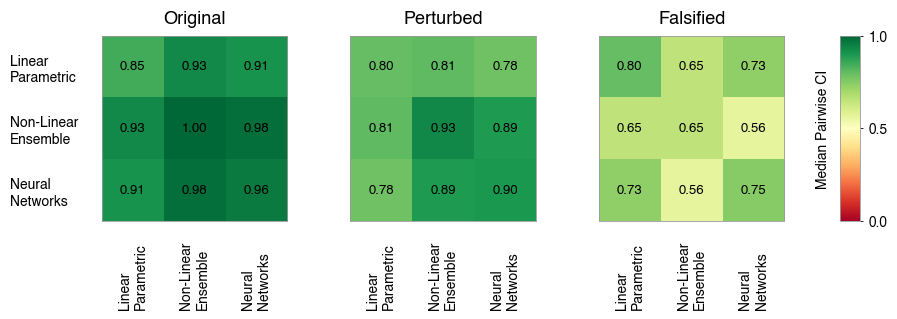

Consensus Superfigure Inputs:
 - Original: 36 Model-Pair Rows
 - Perturbed: 432 Max-Intensity Model-Pair Rows (Live Perturbed Consensus Results)
 - Falsified: 108 Frozen Falsified Model-Pair Rows (Live Falsified Consensus Results)
Saved Superfigure To: /Users/nickkunz/Documents/Nick’s MacBook Pro/Python/graph-capacity/outputs/figures/consensus_ci_superfigure.png


In [735]:
## ci-only consensus superfigure
import logging
import pickle
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.text import Text

from src.data.builders import (
    load_falsified_data,
    load_perturbed_data,
    load_processed_data,
)
from src.estimators.factories.registry import load_estimators
from src.evaluators.config import (
    FEAT_X,
    FEAT_Z,
    TARGET,
)
from src.evaluators.falsifying import (
    compile_falsified_consensus,
    train_falsified_consensus,
)
from src.evaluators.metrics import consensus_metrics
from src.evaluators.perturbing import (
    compile_perturbed_consensus,
    find_perturbed_max,
    train_perturbed_consensus,
)
from src.evaluators.training import fit_predict_frontier
from src.visualizers.visualizing import (
    DEFAULT_PARADIGM_ORDER,
    build_paradigm_consensus_matrices,
)

## configuration
N_DECIMALS = int(globals().get("N_DECIMALS", 2))
N_REPEATS = int(globals().get("N_REPEATS", 30))
RANDOM_STATE = int(globals().get("RANDOM_STATE", 42))
root = Path(globals().get("root", Path.cwd().resolve().parent))

existing_data = globals().get("data")
data = existing_data if isinstance(existing_data, pd.DataFrame) else load_processed_data()
existing_models = globals().get("models")
models = existing_models if isinstance(existing_models, dict) else load_estimators(random_state = RANDOM_STATE)

project_root = root
out_dir = project_root / "outputs" / "figures"
out_dir.mkdir(parents = True, exist_ok = True)
cache_dir = project_root / "outputs" / "cache"
cache_dir.mkdir(parents = True, exist_ok = True)
cache_path = cache_dir / "consensus_ci_superfigure_results.pkl"

PERTURBATION_KEYS = [
    "network_perturbed",
    "invariants_perturbed",
    "process_perturbed",
    "signatures_perturbed",
]


def _cache_metadata() -> dict[str, object]:
    return {
        "n_obs": len(data),
        "random_state": RANDOM_STATE,
        "n_repeats": N_REPEATS,
        "model_names": sorted(models.keys()),
    }


def _load_superfigure_cache() -> dict[str, object] | None:
    if not cache_path.exists():
        return None
    with open(cache_path, "rb") as file_handle:
        cached = pickle.load(file_handle)
    if cached.get("metadata") != _cache_metadata():
        return None
    return cached


def _save_superfigure_cache(
    perturbed_results: pd.DataFrame,
    falsified_results: pd.DataFrame,
) -> None:
    payload = {
        "metadata": _cache_metadata(),
        "results_perturbed_consensus": perturbed_results,
        "results_falsified_consensus": falsified_results,
    }
    with open(cache_path, "wb") as file_handle:
        pickle.dump(payload, file_handle)


def _load_perturbed_subset() -> dict:
    existing = globals().get("data_pert")
    if isinstance(existing, dict) and existing:
        return existing

    disable_level = logging.root.manager.disable
    logging.disable(logging.INFO)
    try:
        data_pert_all = load_perturbed_data()
    finally:
        logging.disable(disable_level)

    data_pert_subset = {
        key: data_pert_all[key]
        for key in PERTURBATION_KEYS
        if key in data_pert_all
    }
    if not data_pert_subset:
        raise RuntimeError("No supported perturbation payloads were loaded.")
    globals()["data_pert"] = data_pert_subset
    return data_pert_subset


def _load_falsified_subset() -> dict[str, pd.DataFrame]:
    existing = globals().get("data_fals")
    if isinstance(existing, dict) and existing:
        return existing

    disable_level = logging.root.manager.disable
    logging.disable(logging.INFO)
    try:
        data_falsified = load_falsified_data()
    finally:
        logging.disable(disable_level)

    if not data_falsified:
        raise RuntimeError("No falsification payloads were loaded.")
    globals()["data_fals"] = data_falsified
    return data_falsified


def _compile_original_consensus() -> pd.DataFrame:
    existing = globals().get("results_data")
    required_columns = {"model_i", "model_j", "ci"}
    if isinstance(existing, pd.DataFrame) and required_columns.issubset(existing.columns):
        return existing.copy()

    source_frontiers = globals().get("frontiers")
    if not isinstance(source_frontiers, dict) or len(source_frontiers) != len(models):
        print("Computing Original Pairwise Consensus...")
        source_frontiers = dict()
        for model_name, model in models.items():
            print(f"  {model_name}")
            fit_result = fit_predict_frontier(
                data = data,
                feat_x = FEAT_X,
                feat_z = FEAT_Z,
                estimator_c = model.estimator_c,
                estimator_r = model.estimator_r,
                target = TARGET,
                n_repeat = N_REPEATS,
                random_state = RANDOM_STATE,
            )
            source_frontiers[model_name] = fit_result["y_pred"]
        globals()["frontiers"] = source_frontiers

    rows = list()
    for (model_i, pred_i), (model_j, pred_j) in combinations(source_frontiers.items(), 2):
        pred_i = np.asarray(pred_i, dtype = float)
        pred_j = np.asarray(pred_j, dtype = float)
        valid = np.isfinite(pred_i) & np.isfinite(pred_j)
        if int(np.sum(valid)) < 2:
            continue
        metrics = consensus_metrics(
            y_true = pred_i[valid],
            y_pred = pred_j[valid],
        )
        rows.append({
            "model_i": model_i,
            "model_j": model_j,
            **metrics,
        })

    compiled = pd.DataFrame(rows)
    globals()["results_data"] = compiled
    return compiled


def _compile_perturbed_results(
    cached: dict[str, object] | None,
) -> tuple[pd.DataFrame, str]:
    existing = globals().get("results_perturbed_consensus")
    if isinstance(existing, pd.DataFrame) and not existing.empty:
        return existing.copy(), "Live Perturbed Consensus Results"
    if cached is not None and "results_perturbed_consensus" in cached:
        results = cached["results_perturbed_consensus"]
        if isinstance(results, pd.DataFrame):
            globals()["results_perturbed_consensus"] = results.copy()
            return results.copy(), "Cached Perturbed Consensus Results"

    raw_existing = globals().get("results_dict_perturbed_consensus")
    if raw_existing is not None:
        results = compile_perturbed_consensus(
            results = raw_existing,
        )
        globals()["results_perturbed_consensus"] = results
        return results, "Compiled In-Kernel Perturbed Consensus Results"

    print("Computing Perturbed Pairwise Consensus...")
    raw_results = train_perturbed_consensus(
        data = data,
        models = models,
        data_pert = _load_perturbed_subset(),
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE,
    )
    results = compile_perturbed_consensus(
        results = raw_results,
    )
    globals()["results_dict_perturbed_consensus"] = raw_results
    globals()["results_perturbed_consensus"] = results
    return results, "Freshly Computed Perturbed Consensus Results"


def _compile_falsified_results(
    cached: dict[str, object] | None,
) -> tuple[pd.DataFrame, str]:
    existing = globals().get("results_falsified_consensus")
    if isinstance(existing, pd.DataFrame) and not existing.empty:
        return existing.copy(), "Live Falsified Consensus Results"
    if cached is not None and "results_falsified_consensus" in cached:
        results = cached["results_falsified_consensus"]
        if isinstance(results, pd.DataFrame):
            globals()["results_falsified_consensus"] = results.copy()
            return results.copy(), "Cached Falsified Consensus Results"

    raw_existing = globals().get("results_dict_falsified_consensus")
    if raw_existing is not None:
        results = compile_falsified_consensus(
            results = raw_existing,
        )
        globals()["results_falsified_consensus"] = results
        return results, "Compiled In-Kernel Falsified Consensus Results"

    print("Computing Falsified Pairwise Consensus...")
    raw_results = train_falsified_consensus(
        data_proc = data,
        data_fals = _load_falsified_subset(),
        models = models,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE,
    )
    results = compile_falsified_consensus(
        results = raw_results,
    )
    globals()["results_dict_falsified_consensus"] = raw_results
    globals()["results_falsified_consensus"] = results
    return results, "Freshly Computed Falsified Consensus Results"


def _ci_matrix(results: pd.DataFrame) -> pd.DataFrame:
    matrix = build_paradigm_consensus_matrices(
        results = results,
        paradigm_order = DEFAULT_PARADIGM_ORDER,
        metric_panels = {"CI": "ci"},
    )["CI"]
    values = matrix.to_numpy(dtype = float)
    if not np.any(np.isfinite(values)):
        raise RuntimeError("No Finite CI Values Were Available For Plotting.")
    return matrix


def _stack_display_label(label: str) -> str:
    return "\n".join(word.title() for word in label.split())


cached_payload = _load_superfigure_cache()
results_original_ci = _compile_original_consensus()
results_perturbed_ci, perturbed_source = _compile_perturbed_results(
    cached = cached_payload,
)
results_falsified_ci, falsified_source = _compile_falsified_results(
    cached = cached_payload,
)
_save_superfigure_cache(
    perturbed_results = results_perturbed_ci,
    falsified_results = results_falsified_ci,
)

## condition-specific plotting frames
results_perturbed_max = find_perturbed_max(
    results = results_perturbed_ci,
)
results_perturbed_plot = results_perturbed_max.loc[
    results_perturbed_max["perturbation"] != "baseline"
] .copy()
if results_perturbed_plot.empty:
    raise RuntimeError("No Non-Baseline Perturbed Consensus Rows Were Available For Plotting.")

results_falsified_plot = results_falsified_ci.copy()
if "condition" in results_falsified_plot.columns:
    results_falsified_plot = results_falsified_plot.loc[
        results_falsified_plot["condition"] == "falsified"
    ].copy()
if "Falsification" in results_falsified_plot.columns:
    frozen_rows = results_falsified_plot["Falsification"] == "frozen"
    if frozen_rows.any():
        results_falsified_plot = results_falsified_plot.loc[frozen_rows].copy()
if results_falsified_plot.empty:
    raise RuntimeError("No Falsified Consensus Rows Were Available For Plotting.")

condition_matrices = {
    "Original": _ci_matrix(results_original_ci),
    "Perturbed": _ci_matrix(results_perturbed_plot),
    "Falsified": _ci_matrix(results_falsified_plot),
}

## figure scaffold
plt.close("all")
FONT_FAMILY = ["Helvetica", "Arial", "sans-serif"]
TEXT_COLOR = "#000000"
SPINE_COLOR = "#9A9A9A"
AXIS_LABEL_FONT_SIZE = 10.0
HEATMAP_VALUE_FONT_SIZE = 9.5
COLORBAR_PAD = 0.05
COLORBAR_WIDTH = 0.018

paradigm_order = list(DEFAULT_PARADIGM_ORDER)
display_paradigm_order = [_stack_display_label(label = label) for label in paradigm_order]
fig, axes = plt.subplots(
    nrows = 1,
    ncols = len(condition_matrices),
    figsize = (11.1, 5.25),
    facecolor = "white",
)
fig.subplots_adjust(
    left = 0.265,
    right = 0.88,
    top = 0.82,
    bottom = 0.46,
    wspace = 0.34,
)
axes_array = np.atleast_1d(axes).ravel()
norm = Normalize(vmin = 0.0, vmax = 1.0)
cmap = plt.get_cmap("RdYlGn").copy()
cmap.set_bad(color = "#F7F7F7")
image = None
value_label_artists = list()
bottom_label_artists = list()


for panel_index, (axis, (condition_label, matrix)) in enumerate(zip(axes_array, condition_matrices.items())):
    values = matrix.to_numpy(dtype = float)
    image = axis.imshow(
        np.ma.masked_invalid(values),
        cmap = cmap,
        norm = norm,
        aspect = "equal",
        interpolation = "nearest",
    )
    axis.set_facecolor("white")

    for row_index, row_label in enumerate(paradigm_order):
        for column_index, column_label in enumerate(paradigm_order):
            value = matrix.loc[row_label, column_label]
            if pd.isna(value):
                label = "NA"
            else:
                label = f"{float(value):.{N_DECIMALS}f}"
            value_label_artists.append(axis.text(
                x = column_index,
                y = row_index,
                s = label,
                ha = "center",
                va = "center",
                fontsize = HEATMAP_VALUE_FONT_SIZE,
                fontweight = "semibold",
                color = TEXT_COLOR,
            ))

    axis.set_title(
        label = condition_label,
        fontsize = 11.0,
        fontweight = "semibold",
        color = TEXT_COLOR,
        y = 1.03,
        pad = 5,
        loc = "center",
    )
    axis.set_xticks(ticks = [])
    for label_index, display_label in enumerate(display_paradigm_order):
        bottom_label_artists.append(axis.text(
            x = label_index,
            y = len(paradigm_order) + 0.92,
            s = display_label,
            transform = axis.transData,
            rotation = 90,
            rotation_mode = "default",
            ha = "center",
            va = "bottom",
            multialignment = "left",
            fontsize = 8.5,
            color = TEXT_COLOR,
            clip_on = False,
        ))
    axis.set_yticks(ticks = range(len(paradigm_order)))
    if panel_index == 0:
        axis.set_yticklabels(
            labels = display_paradigm_order,
            fontsize = 8.5,
            color = TEXT_COLOR,
        )
        for tick_label in axis.get_yticklabels():
            tick_label.set_x(-0.36)
            tick_label.set_horizontalalignment("left")
            tick_label.set_multialignment("left")
    else:
        axis.set_yticklabels(labels = [])
    axis.tick_params(axis = "x", which = "major", length = 0, color = SPINE_COLOR, pad = 0)
    axis.tick_params(axis = "y", which = "major", length = 0, color = SPINE_COLOR, pad = 18)
    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_color(SPINE_COLOR)
        spine.set_linewidth(0.6)

if image is not None:
    panel_position = axes_array[-1].get_position()
    colorbar_axis = fig.add_axes([
        panel_position.x1 + COLORBAR_PAD,
        panel_position.y0,
        COLORBAR_WIDTH,
        panel_position.height,
    ])
    colorbar_axis.set_facecolor("white")
    colorbar = fig.colorbar(image, cax = colorbar_axis)
    colorbar.set_ticks([0.0, 0.5, 1.0])
    colorbar.set_ticklabels(["0.0", "0.5", "1.0"])
    colorbar.set_label(
        label = "Median Pairwise CI",
        fontsize = 8.0,
        color = TEXT_COLOR,
        labelpad = 7,
    )
    colorbar.ax.yaxis.set_label_position("left")
    colorbar.ax.tick_params(
        labelsize = 8.0,
        colors = TEXT_COLOR,
        length = 2.5,
        width = 0.6,
    )
    colorbar.outline.set_edgecolor(SPINE_COLOR)
    colorbar.outline.set_linewidth(0.6)

for text_artist in fig.findobj(match = Text):
    text_artist.set_fontfamily(FONT_FAMILY)
    text_artist.set_fontsize(text_artist.get_fontsize() + 2.0)

for label_artist in value_label_artists:
    label_artist.set_fontsize(HEATMAP_VALUE_FONT_SIZE)

for label_artist in bottom_label_artists:
    label_artist.set_fontsize(AXIS_LABEL_FONT_SIZE)

for axis in axes_array:
    for tick_label in axis.get_yticklabels():
        tick_label.set_fontsize(AXIS_LABEL_FONT_SIZE)

fig.canvas.draw()

## save
png_path = out_dir / "consensus_ci_superfigure.png"
pdf_path = out_dir / "consensus_ci_superfigure.pdf"
fig.savefig(png_path, dpi = 300, facecolor = fig.get_facecolor(), bbox_inches = "tight")
fig.savefig(pdf_path, dpi = 300, facecolor = fig.get_facecolor(), bbox_inches = "tight")
plt.show()

print("Consensus Superfigure Inputs:")
print(f" - Original: {len(results_original_ci)} Model-Pair Rows")
print(f" - Perturbed: {len(results_perturbed_plot)} Max-Intensity Model-Pair Rows ({perturbed_source})")
print(f" - Falsified: {len(results_falsified_plot)} Frozen Falsified Model-Pair Rows ({falsified_source})")
print(f"Saved Superfigure To: {png_path}")

In [736]:
## n3s stress-test data preparation -- cache-backed
import logging
import pickle
import sys
from pathlib import Path

import pandas as pd

notebook_cwd = Path.cwd().resolve()
project_root = Path(
    globals().get(
        "root",
        notebook_cwd.parent if notebook_cwd.name == "notebooks" else notebook_cwd,
    )
).resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
root = project_root

from src.data.builders import (
    load_falsified_data,
    load_perturbed_data,
    load_processed_data,
)
from src.estimators.factories import load_estimators
from src.evaluators.config import FEAT_X, FEAT_Z, TARGET
from src.evaluators.decomposing import (
    compile_decomposed_separation,
    train_decomposed_separation,
)
from src.evaluators.falsifying import (
    compile_falsified_agreement,
    compile_falsified_transfer,
    train_falsified_agreement,
    train_falsified_transfer,
)
from src.evaluators.metrics import spec_marginal_delta
from src.evaluators.perturbing import (
    compile_perturbed_recovery,
    compile_perturbed_transfer,
    find_perturbed_max,
    train_perturbed_recovery,
    train_perturbed_transfer,
)

out_dir = project_root / "outputs" / "figures"
out_dir.mkdir(parents = True, exist_ok = True)
stress_cache_dir = project_root / "outputs" / "cache"
stress_cache_dir.mkdir(parents = True, exist_ok = True)
stress_cache_path = stress_cache_dir / "n3s_stress_test_superfigure_results.pkl"

N_DECIMALS_WORK = int(globals().get("N_DECIMALS", 2))
N_REPEATS_WORK = int(globals().get("N_REPEATS", 30))
RANDOM_STATE_WORK = int(globals().get("RANDOM_STATE", 42))
PERTURBATION_KEYS = [
    "network_perturbed",
    "invariants_perturbed",
    "process_perturbed",
    "signatures_perturbed",
]
STRESS_RESULT_NAMES = [
    "results_pert_transfer",
    "results_pert_recovery",
    "results_fals_transfer",
    "results_fals_agreement",
    "results_decomp",
]


def _stress_cache_metadata(data_frame: pd.DataFrame, model_dict: dict) -> dict[str, object]:
    return {
        "n_obs": len(data_frame),
        "random_state": RANDOM_STATE_WORK,
        "n_repeats": N_REPEATS_WORK,
        "model_names": sorted(model_dict.keys()),
    }


def _load_stress_cache(data_frame: pd.DataFrame, model_dict: dict) -> dict | None:
    if not stress_cache_path.exists():
        return None
    with open(file = stress_cache_path, mode = "rb") as file_handle:
        cached = pickle.load(file_handle)
    if cached.get("metadata") != _stress_cache_metadata(
        data_frame = data_frame,
        model_dict = model_dict,
    ):
        return None
    return cached


def _save_stress_cache(data_frame: pd.DataFrame, model_dict: dict, payload: dict) -> None:
    serializable_payload = dict(payload)
    serializable_payload["metadata"] = _stress_cache_metadata(
        data_frame = data_frame,
        model_dict = model_dict,
    )
    with open(file = stress_cache_path, mode = "wb") as file_handle:
        pickle.dump(serializable_payload, file_handle)


print("Preparing N3S stress-test superfigure inputs...")
_disable_level = logging.root.manager.disable
logging.disable(logging.INFO)
try:
    data_local = data if isinstance(globals().get("data"), pd.DataFrame) else load_processed_data()
    models_local = models if isinstance(globals().get("models"), dict) else load_estimators(
        random_state = RANDOM_STATE_WORK,
    )
finally:
    logging.disable(_disable_level)

data = data_local
models = models_local
cached_payload = _load_stress_cache(
    data_frame = data_local,
    model_dict = models_local,
)

if cached_payload is None and all(name in globals() for name in STRESS_RESULT_NAMES):
    print("  Using in-memory stress-test result tables.")
    cached_payload = {name: globals()[name] for name in STRESS_RESULT_NAMES}
    _save_stress_cache(
        data_frame = data_local,
        model_dict = models_local,
        payload = cached_payload,
    )

if cached_payload is None:
    print("  Cache miss: computing perturbation, falsification, and decomposition tables...")

    _disable_level = logging.root.manager.disable
    logging.disable(logging.INFO)
    try:
        data_pert_all = load_perturbed_data()
    finally:
        logging.disable(_disable_level)
    data_pert = {
        key: data_pert_all[key]
        for key in PERTURBATION_KEYS
        if key in data_pert_all
    }
    if not data_pert:
        raise RuntimeError("No supported perturbation payloads were loaded.")

    results_dict_pert_transfer = train_perturbed_transfer(
        data = data_local,
        models = models_local,
        data_pert = data_pert,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
    )
    results_pert_transfer, _ = compile_perturbed_transfer(
        results = results_dict_pert_transfer,
    )

    results_dict_pert_recovery = train_perturbed_recovery(
        data = data_local,
        models = models_local,
        data_pert = data_pert,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS_WORK,
        random_state = RANDOM_STATE_WORK,
    )
    results_pert_recovery = compile_perturbed_recovery(
        results = results_dict_pert_recovery,
    )

    _disable_level = logging.root.manager.disable
    logging.disable(logging.INFO)
    try:
        data_fals = load_falsified_data()
    finally:
        logging.disable(_disable_level)
    if not data_fals:
        raise RuntimeError("No falsification payloads were loaded.")

    results_dict_fals_transfer = train_falsified_transfer(
        data_proc = data_local,
        data_fals = data_fals,
        models = models_local,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        group = "domain",
        n_repeats = N_REPEATS_WORK,
        random_state = RANDOM_STATE_WORK,
    )
    results_fals_transfer = compile_falsified_transfer(
        results = results_dict_fals_transfer,
    )

    results_dict_fals_agreement = train_falsified_agreement(
        data_proc = data_local,
        data_fals = data_fals,
        models = models_local,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS_WORK,
        random_state = RANDOM_STATE_WORK,
    )
    results_fals_agreement = compile_falsified_agreement(
        results = results_dict_fals_agreement,
    )

    results_dict_decomp = train_decomposed_separation(
        data = data_local,
        models = models_local,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS_WORK,
        random_state = RANDOM_STATE_WORK,
    )
    results_decomp, _ = compile_decomposed_separation(
        results = results_dict_decomp,
    )

    cached_payload = {
        "results_pert_transfer": results_pert_transfer,
        "results_pert_recovery": results_pert_recovery,
        "results_fals_transfer": results_fals_transfer,
        "results_fals_agreement": results_fals_agreement,
        "results_decomp": results_decomp,
    }
    _save_stress_cache(
        data_frame = data_local,
        model_dict = models_local,
        payload = cached_payload,
    )
else:
    print("  Cache hit: using saved stress-test result tables.")

results_pert_transfer = cached_payload["results_pert_transfer"]
results_pert_recovery = cached_payload["results_pert_recovery"]
results_fals_transfer = cached_payload["results_fals_transfer"]
results_fals_agreement = cached_payload["results_fals_agreement"]
results_decomp = cached_payload["results_decomp"]

results_pert_transfer_max = find_perturbed_max(
    results = results_pert_transfer,
)
results_pert_recovery_max = find_perturbed_max(
    results = results_pert_recovery,
)
delta_pert_ei = spec_marginal_delta(
    results = results_pert_transfer,
    feat_value = ["ei"],
    track = "frozen",
    label_ref = "perturbation",
    method = "iqr",
    scale = 1.0,
    decimals = N_DECIMALS_WORK,
)
delta_pert_ci = spec_marginal_delta(
    results = results_pert_recovery,
    feat_value = ["ci"],
    label_pert = "perturbation",
    track = "frozen",
    method = "iqr",
    scale = 0.33,
    decimals = N_DECIMALS_WORK + 1,
)
delta_decomp_ei = spec_marginal_delta(
    results = results_decomp,
    feat_value = ["ei"],
    label_ref = "specification",
    value_ref = "additive",
    method = "iqr",
    scale = 1.0,
    decimals = N_DECIMALS_WORK,
)
delta_decomp_ci = spec_marginal_delta(
    results = results_decomp,
    feat_value = ["ci"],
    label_ref = "specification",
    value_ref = "additive",
    method = "iqr",
    scale = 0.33,
    decimals = N_DECIMALS_WORK,
)

print("Prepared stress-test inputs:")
print(f"  perturbation transfer rows: {len(results_pert_transfer)}")
print(f"  perturbation recovery rows: {len(results_pert_recovery)}")
print(f"  falsification transfer rows: {len(results_fals_transfer)}")
print(f"  falsification agreement rows: {len(results_fals_agreement)}")
print(f"  decomposition rows: {len(results_decomp)}")
print(f"  cache: {stress_cache_path}")

Preparing N3S stress-test superfigure inputs...
  Cache hit: using saved stress-test result tables.
Prepared stress-test inputs:
  perturbation transfer rows: 7650
  perturbation recovery rows: 3825
  falsification transfer rows: 540
  falsification agreement rows: 540
  decomposition rows: 270
  cache: /Users/nickkunz/Documents/Nick’s MacBook Pro/Python/graph-capacity/outputs/cache/n3s_stress_test_superfigure_results.pkl


Rendering axis-aligned N3S stress-test superfigure...
Text scale check: falsification = 1.140, ablation = 1.140
Panel size check: perturbation = 0.1303 x 0.1818, falsification = 0.1303 x 0.1818, ablation = 0.1303 x 0.1818
Column alignment check: falsification max Delta = 0.000000, ablation max Delta = 0.000000
Outer x-label spacing check: perturbation = 0.0067, falsification = 0.0067, ablation = 0.0067
2026-05-15 23:13:49,040 - INFO - maxp pruned
2026-05-15 23:13:49,040 - INFO - cmap pruned
2026-05-15 23:13:49,041 - WARNING - 1 extra bytes in post.stringData array
2026-05-15 23:13:49,041 - INFO - kern pruned
2026-05-15 23:13:49,042 - INFO - post pruned
2026-05-15 23:13:49,042 - INFO - meta dropped
2026-05-15 23:13:49,043 - WARNING - 'created' timestamp seems very low; regarding as unix timestamp
2026-05-15 23:13:49,044 - INFO - glyf pruned
2026-05-15 23:13:49,045 - INFO - Added gid0 to subset
2026-05-15 23:13:49,045 - INFO - Added first four glyphs to subset
2026-05-15 23:13:49,046 - I

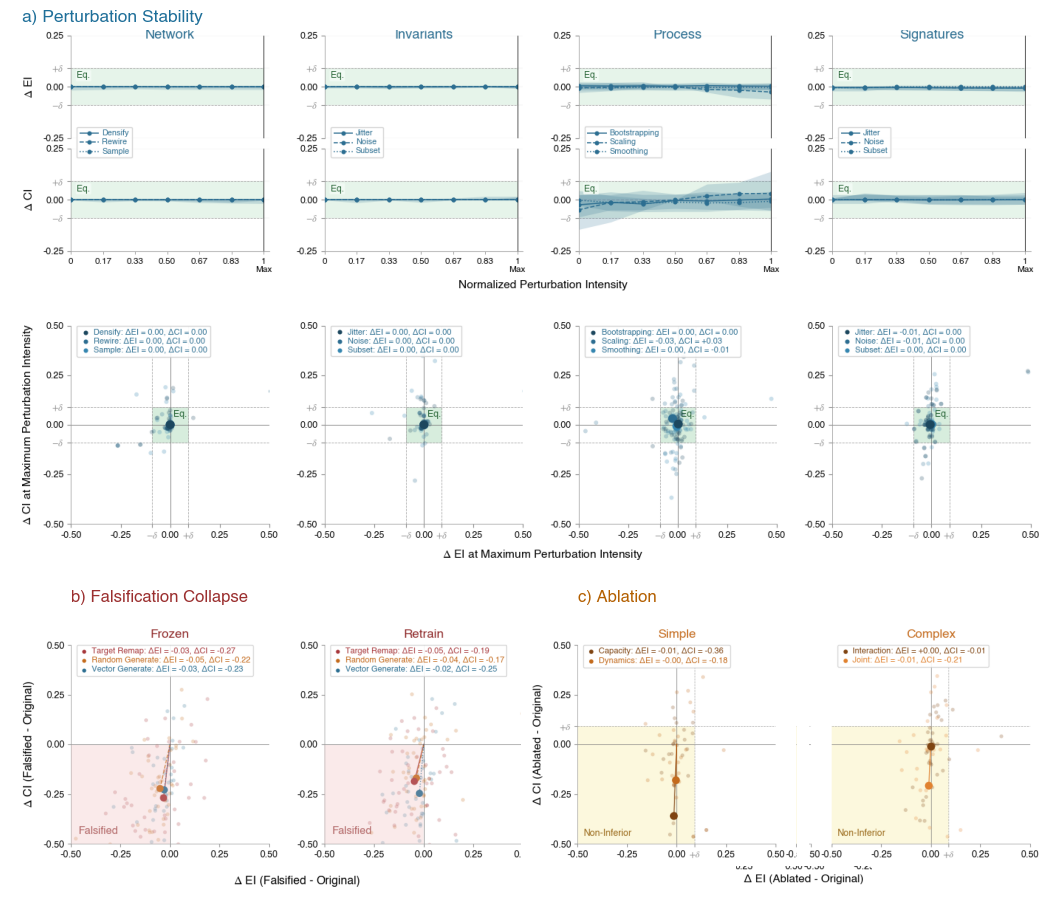

Axis-aligned N3S stress-test superfigure refreshed.
Saved PNG to: /Users/nickkunz/Documents/Nick’s MacBook Pro/Python/graph-capacity/outputs/figures/n3s_stress_test_superfigure.png
Saved PDF to: /Users/nickkunz/Documents/Nick’s MacBook Pro/Python/graph-capacity/outputs/figures/n3s_stress_test_superfigure.pdf


In [737]:
## n3s stress-test superfigure render -- axis-aligned
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.text import Text
from matplotlib.transforms import Bbox

notebook_cwd = Path.cwd().resolve()
project_root = Path(
    globals().get(
        "root",
        notebook_cwd.parent if notebook_cwd.name == "notebooks" else notebook_cwd,
    )
).resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
out_dir = project_root / "outputs" / "figures"
out_dir.mkdir(parents = True, exist_ok = True)

from src.visualizers.visualizing import (
    plot_decomposition_moneyshot,
    plot_falsification_track_fingerprint,
    plot_perturbation_superfigure,
)

required_stress_names = [
    "results_pert_transfer",
    "results_pert_recovery",
    "results_pert_transfer_max",
    "results_pert_recovery_max",
    "delta_pert_ei",
    "delta_pert_ci",
    "results_fals_transfer",
    "results_fals_agreement",
    "delta_decomp_ei",
    "delta_decomp_ci",
    "results_decomp",
]
missing_stress_names = [
    name
    for name in required_stress_names
    if name not in globals()
]
if missing_stress_names:
    raise RuntimeError(
        "Run the N3S stress-test data preparation cell before rendering; "
        f"missing: {missing_stress_names}"
    )

HEADING_FONT_FAMILY = ["Helvetica", "Arial", "sans-serif"]


def _figure_to_rgba_with_crop(
    figure: plt.Figure,
    white_threshold: int = 248,
    ) -> tuple[np.ndarray, tuple[int, int, int, int], tuple[int, int]]:

    figure.canvas.draw()
    width, height = figure.canvas.get_width_height()
    image = np.frombuffer(
        figure.canvas.buffer_rgba(),
        dtype = np.uint8,
    ).reshape(height, width, 4)

    rgb = image[:, :, :3]
    alpha = image[:, :, 3]
    keep = np.any(rgb < white_threshold, axis = 2) & (alpha > 0)
    if not np.any(keep):
        return image.copy(), (0, height, 0, width), (width, height)

    rows = np.where(np.any(keep, axis = 1))[0]
    cols = np.where(np.any(keep, axis = 0))[0]
    row_start = int(rows[0])
    row_stop = int(rows[-1] + 1)
    col_start = int(cols[0])
    col_stop = int(cols[-1] + 1)
    return (
        image[row_start:row_stop, col_start:col_stop, :].copy(),
        (row_start, row_stop, col_start, col_stop),
        (width, height),
    )


def _bbox_fraction_from_crop(
    bbox: Bbox,
    crop_box: tuple[int, int, int, int],
    original_size: tuple[int, int],
    ) -> tuple[float, float, float, float]:

    width, height = original_size
    row_start, row_stop, col_start, col_stop = crop_box
    crop_width = float(col_stop - col_start)
    crop_height = float(row_stop - row_start)
    crop_bottom = float(height - row_stop)

    return (
        (bbox.x0 - col_start) / crop_width,
        (bbox.y0 - crop_bottom) / crop_height,
        (bbox.x1 - col_start) / crop_width,
        (bbox.y1 - crop_bottom) / crop_height,
    )


def _axes_bbox_fraction(
    figure: plt.Figure,
    axes: object,
    crop_box: tuple[int, int, int, int],
    original_size: tuple[int, int],
    ) -> tuple[float, float, float, float]:

    figure.canvas.draw()
    renderer = figure.canvas.get_renderer()
    bbox = Bbox.union([
        axis.get_window_extent(renderer = renderer)
        for axis in np.ravel(axes)
    ])
    return _bbox_fraction_from_crop(
        bbox = bbox,
        crop_box = crop_box,
        original_size = original_size,
    )


def _axes_extent_pixels(figure: plt.Figure, axes: object) -> tuple[float, float]:
    figure.canvas.draw()
    renderer = figure.canvas.get_renderer()
    bbox = Bbox.union([
        axis.get_window_extent(renderer = renderer)
        for axis in np.ravel(axes)
    ])
    return float(bbox.width), float(bbox.height)


def _scale_text_to_match_panel_scale(
    figure: plt.Figure,
    source_axes: object,
    target_figure: plt.Figure,
    target_axes: object,
    ) -> float:

    source_width, source_height = _axes_extent_pixels(
        figure = figure,
        axes = source_axes,
    )
    target_width, target_height = _axes_extent_pixels(
        figure = target_figure,
        axes = target_axes,
    )
    width_scale = source_width / target_width
    height_scale = source_height / target_height
    text_scale = float(np.sqrt(width_scale * height_scale))

    for text_artist in figure.findobj(match = Text):
        text_artist.set_fontsize(text_artist.get_fontsize() * text_scale)
    for axis in np.ravel(source_axes):
        axis.xaxis.label.set_fontsize(axis.xaxis.label.get_fontsize() * text_scale)
    figure.canvas.draw()
    return text_scale


def _normalize_text_label(label: str) -> str:
    normalized = str(label)
    for old_value, new_value in {
        r"\Delta": "Delta",
        chr(916): "Delta",
        "$": "",
        "{": "",
        "}": "",
    }.items():
        normalized = normalized.replace(old_value, new_value)
    return " ".join(normalized.split())


def _find_native_text_artist(
    figure: plt.Figure,
    required_fragments: tuple[str, ...],
    ) -> Text:

    normalized_fragments = tuple(
        _normalize_text_label(label = fragment)
        for fragment in required_fragments
    )
    matches = [
        text_artist
        for text_artist in figure.findobj(match = Text)
        if all(
            fragment in _normalize_text_label(label = text_artist.get_text())
            for fragment in normalized_fragments
        )
    ]
    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one native text artist matching {required_fragments}; found {len(matches)}."
        )
    return matches[0]


def _text_artist_to_rgba(
    figure: plt.Figure,
    text_artist: Text,
    pad_pixels: int = 12,
    ) -> np.ndarray:

    figure.canvas.draw()
    width, height = figure.canvas.get_width_height()
    image = np.frombuffer(
        figure.canvas.buffer_rgba(),
        dtype = np.uint8,
    ).reshape(height, width, 4)
    renderer = figure.canvas.get_renderer()
    bbox = text_artist.get_window_extent(renderer = renderer)

    if bbox.width <= 0 or bbox.height <= 0:
        raise RuntimeError(f"Native text artist has an empty bbox: {text_artist.get_text()}")

    col_start = int(max(0, np.floor(bbox.x0 - pad_pixels)))
    col_stop = int(min(width, np.ceil(bbox.x1 + pad_pixels)))
    row_start = int(max(0, np.floor(height - bbox.y1 - pad_pixels)))
    row_stop = int(min(height, np.ceil(height - bbox.y0 + pad_pixels)))
    return image[row_start:row_stop, col_start:col_stop, :].copy()


def _native_xlabel_gap_fraction(
    figure: plt.Figure,
    axis: object,
    text_artist: Text,
    crop_box: tuple[int, int, int, int],
    original_size: tuple[int, int],
    ) -> float:

    figure.canvas.draw()
    renderer = figure.canvas.get_renderer()
    xaxis_bbox = axis.xaxis.get_tightbbox(renderer = renderer)
    if xaxis_bbox is None:
        xaxis_bbox = axis.get_window_extent(renderer = renderer)
    label_bbox = text_artist.get_window_extent(renderer = renderer)
    xaxis_box = _bbox_fraction_from_crop(
        bbox = xaxis_bbox,
        crop_box = crop_box,
        original_size = original_size,
    )
    label_box = _bbox_fraction_from_crop(
        bbox = label_bbox,
        crop_box = crop_box,
        original_size = original_size,
    )
    return float(xaxis_box[1] - label_box[3])


def _axis_to_panel_image(
    figure: plt.Figure,
    axis: object,
    pad_pixels: int = 18,
    ) -> tuple[
        np.ndarray,
        tuple[float, float, float, float],
        tuple[float, float, float, float],
        ]:

    figure.canvas.draw()
    width, height = figure.canvas.get_width_height()
    image = np.frombuffer(
        figure.canvas.buffer_rgba(),
        dtype = np.uint8,
    ).reshape(height, width, 4)
    renderer = figure.canvas.get_renderer()

    tight_boxes = [
        axis.get_tightbbox(renderer = renderer),
        axis.get_window_extent(renderer = renderer),
    ]
    legend = axis.get_legend()
    if legend is not None:
        tight_boxes.append(legend.get_window_extent(renderer = renderer))
    tight_boxes = [box for box in tight_boxes if box is not None]
    tight_box = Bbox.union(tight_boxes)

    col_start = int(max(0, np.floor(tight_box.x0 - pad_pixels)))
    col_stop = int(min(width, np.ceil(tight_box.x1 + pad_pixels)))
    row_start = int(max(0, np.floor(height - tight_box.y1 - pad_pixels)))
    row_stop = int(min(height, np.ceil(height - tight_box.y0 + pad_pixels)))
    crop_box = (row_start, row_stop, col_start, col_stop)
    original_size = (width, height)
    source_bbox = _axes_bbox_fraction(
        figure = figure,
        axes = [axis],
        crop_box = crop_box,
        original_size = original_size,
    )
    xaxis_bbox = axis.xaxis.get_tightbbox(renderer = renderer)
    if xaxis_bbox is None:
        xaxis_bbox = axis.get_window_extent(renderer = renderer)
    xaxis_box = _bbox_fraction_from_crop(
        bbox = xaxis_bbox,
        crop_box = crop_box,
        original_size = original_size,
    )
    return image[row_start:row_stop, col_start:col_stop, :].copy(), source_bbox, xaxis_box


def _place_image_panel_aligned(
    figure: plt.Figure,
    image: np.ndarray,
    source_bbox: tuple[float, float, float, float],
    target_bbox: tuple[float, float, float, float],
    zorder: float,
    ) -> object:

    source_x0, source_y0, source_x1, source_y1 = source_bbox
    target_x0, target_y0, target_x1, target_y1 = target_bbox

    axis_width = (target_x1 - target_x0) / (source_x1 - source_x0)
    axis_height = (target_y1 - target_y0) / (source_y1 - source_y0)
    axis_x0 = target_x0 - (source_x0 * axis_width)
    axis_y0 = target_y0 - (source_y0 * axis_height)

    axis = figure.add_axes([axis_x0, axis_y0, axis_width, axis_height], zorder = zorder)
    axis.imshow(image, aspect = "auto")
    axis.set_axis_off()
    return axis


def _place_label_image(
    figure: plt.Figure,
    image: np.ndarray,
    center_x: float,
    top_y: float,
    reference_axis: object,
    reference_image: np.ndarray,
    zorder: float,
    ) -> object:

    reference_position = reference_axis.get_position()
    label_width = image.shape[1] * (reference_position.width / reference_image.shape[1])
    label_height = image.shape[0] * (reference_position.height / reference_image.shape[0])
    axis = figure.add_axes(
        [center_x - (0.5 * label_width), top_y - label_height, label_width, label_height],
        zorder = zorder,
    )
    axis.imshow(image, aspect = "auto")
    axis.set_axis_off()
    return axis


def _mapped_panel_bbox(
    image_position: Bbox,
    panel_box: tuple[float, float, float, float],
    ) -> tuple[float, float, float, float]:

    return (
        image_position.x0 + (panel_box[0] * image_position.width),
        image_position.y0 + (panel_box[1] * image_position.height),
        image_position.x0 + (panel_box[2] * image_position.width),
        image_position.y0 + (panel_box[3] * image_position.height),
    )


def _mapped_panel_size(
    image_position: Bbox,
    panel_box: tuple[float, float, float, float],
    ) -> tuple[float, float]:

    mapped = _mapped_panel_bbox(
        image_position = image_position,
        panel_box = panel_box,
    )
    return mapped[2] - mapped[0], mapped[3] - mapped[1]


def _max_abs_alignment_delta(
    mapped_bbox: tuple[float, float, float, float],
    target_bbox: tuple[float, float, float, float],
    ) -> float:

    return float(np.max(np.abs(np.array(mapped_bbox) - np.array(target_bbox))))


print("Rendering axis-aligned N3S stress-test superfigure...")

fig_pert, axes_pert = plot_perturbation_superfigure(
    results_transfer = results_pert_transfer,
    results_recovery = results_pert_recovery,
    results_transfer_max = results_pert_transfer_max,
    results_recovery_max = results_pert_recovery_max,
    delta_ei = delta_pert_ei,
    delta_ci = delta_pert_ci,
    track = "frozen",
    show = False,
)
fig_fals, axes_fals = plot_falsification_track_fingerprint(
    results_transfer = results_fals_transfer,
    results_agreement = results_fals_agreement,
    figsize = (9.0, 4.5),
    show = False,
)
fig_decomp, axes_decomp = plot_decomposition_moneyshot(
    results = results_decomp,
    delta_ei = delta_decomp_ei,
    delta_ci = delta_decomp_ci,
    specification_order = (
        "interaction",
        "joint",
        "capacity_only",
        "dynamics_only",
    ),
    figsize = (9.0, 4.5),
    show = False,
)

falsification_text_scale = _scale_text_to_match_panel_scale(
    figure = fig_fals,
    source_axes = [np.ravel(axes_fals)[0]],
    target_figure = fig_pert,
    target_axes = [axes_pert[2, 0]],
)
ablation_text_scale = _scale_text_to_match_panel_scale(
    figure = fig_decomp,
    source_axes = [np.ravel(axes_decomp)[0]],
    target_figure = fig_pert,
    target_axes = [axes_pert[2, 0]],
)
print(
    "Text scale check: "
    f"falsification = {falsification_text_scale:.3f}, "
    f"ablation = {ablation_text_scale:.3f}"
)

for axis in np.ravel(axes_decomp)[1:]:
    axis.set_ylabel("")
    axis.tick_params(axis = "y", left = False, labelleft = False)
    axis.spines["left"].set_visible(False)
    axis.yaxis.offsetText.set_visible(False)
    for tick_label in axis.get_yticklabels():
        tick_label.set_visible(False)
fig_decomp.canvas.draw()

perturbation_x_label = _find_native_text_artist(
    figure = fig_pert,
    required_fragments = ("Delta", "EI", "Maximum Perturbation Intensity"),
)
falsification_x_label = _find_native_text_artist(
    figure = fig_fals,
    required_fragments = ("Delta", "EI", "Falsified - Original"),
)
ablation_x_label = _find_native_text_artist(
    figure = fig_decomp,
    required_fragments = ("Delta", "EI", "Ablated - Original"),
)

falsification_x_label_image = _text_artist_to_rgba(
    figure = fig_fals,
    text_artist = falsification_x_label,
)
ablation_x_label_image = _text_artist_to_rgba(
    figure = fig_decomp,
    text_artist = ablation_x_label,
)
falsification_x_label.set_visible(False)
ablation_x_label.set_visible(False)

img_pert, crop_pert, size_pert = _figure_to_rgba_with_crop(figure = fig_pert)
perturbation_label_gap_fraction = _native_xlabel_gap_fraction(
    figure = fig_pert,
    axis = axes_pert[2, 0],
    text_artist = perturbation_x_label,
    crop_box = crop_pert,
    original_size = size_pert,
)
perturbation_axis_boxes = [
    _axes_bbox_fraction(
        figure = fig_pert,
        axes = [axes_pert[2, column_index]],
        crop_box = crop_pert,
        original_size = size_pert,
    )
    for column_index in range(axes_pert.shape[1])
]

falsification_panel_images_and_boxes = [
    _axis_to_panel_image(figure = fig_fals, axis = axis)
    for axis in np.ravel(axes_fals)
]
ablation_panel_images_and_boxes = [
    _axis_to_panel_image(figure = fig_decomp, axis = axis)
    for axis in np.ravel(axes_decomp)
]

plt.close(fig_pert)
plt.close(fig_fals)
plt.close(fig_decomp)
plt.close("all")

fig = plt.figure(figsize = (15.2, 10.9), facecolor = "white")
grid = fig.add_gridspec(
    nrows = 2,
    ncols = 4,
    height_ratios = [1.85, 1.0],
    width_ratios = [1.0, 1.0, 1.0, 1.0],
    hspace = 0.24,
    wspace = 0.28,
    left = 0.035,
    right = 0.99,
    top = 0.89,
    bottom = 0.05,
)

ax_top = fig.add_subplot(grid[0, :])
ax_bottom_slot_left = fig.add_subplot(grid[1, 0:2])
ax_bottom_slot_right = fig.add_subplot(grid[1, 2:4])
for axis in (ax_top, ax_bottom_slot_left, ax_bottom_slot_right):
    axis.set_axis_off()

ax_top.imshow(img_pert)
fig.canvas.draw()
top_position = ax_top.get_position()
bottom_left_position = ax_bottom_slot_left.get_position()
ax_bottom_slot_left.remove()
ax_bottom_slot_right.remove()

column_boxes = [
    (
        top_position.x0 + (axis_box[0] * top_position.width),
        top_position.y0 + (axis_box[1] * top_position.height),
        top_position.x0 + (axis_box[2] * top_position.width),
        top_position.y0 + (axis_box[3] * top_position.height),
    )
    for axis_box in perturbation_axis_boxes
]
perturbation_panel_height = column_boxes[0][3] - column_boxes[0][1]
bottom_axis_center_y = bottom_left_position.y0 + (0.70 * bottom_left_position.height)
bottom_panel_y0 = bottom_axis_center_y - (0.5 * perturbation_panel_height)
bottom_panel_y1 = bottom_axis_center_y + (0.5 * perturbation_panel_height)
bottom_column_boxes = [
    (column_box[0], bottom_panel_y0, column_box[2], bottom_panel_y1)
    for column_box in column_boxes
]

perturbation_label_gap = perturbation_label_gap_fraction * top_position.height
falsification_target_x = (bottom_column_boxes[0][0], bottom_column_boxes[1][2])
ablation_target_x = (bottom_column_boxes[2][0], bottom_column_boxes[3][2])

falsification_panel_axes = []
for panel_index, (panel_image, source_bbox, _) in enumerate(falsification_panel_images_and_boxes):
    falsification_panel_axes.append(
        _place_image_panel_aligned(
            figure = fig,
            image = panel_image,
            source_bbox = source_bbox,
            target_bbox = bottom_column_boxes[panel_index],
            zorder = 2,
        )
    )

ablation_panel_axes = []
for panel_index, (panel_image, source_bbox, _) in enumerate(ablation_panel_images_and_boxes):
    ablation_panel_axes.append(
        _place_image_panel_aligned(
            figure = fig,
            image = panel_image,
            source_bbox = source_bbox,
            target_bbox = bottom_column_boxes[panel_index + 2],
            zorder = 2,
        )
    )

falsification_tick_bottom = min(
    _mapped_panel_bbox(
        image_position = falsification_panel_axes[index].get_position(),
        panel_box = falsification_panel_images_and_boxes[index][2],
    )[1]
    for index in range(len(falsification_panel_axes))
)
ablation_tick_bottom = min(
    _mapped_panel_bbox(
        image_position = ablation_panel_axes[index].get_position(),
        panel_box = ablation_panel_images_and_boxes[index][2],
    )[1]
    for index in range(len(ablation_panel_axes))
)
falsification_label_axis = _place_label_image(
    figure = fig,
    image = falsification_x_label_image,
    center_x = 0.5 * (falsification_target_x[0] + falsification_target_x[1]),
    top_y = falsification_tick_bottom - perturbation_label_gap,
    reference_axis = falsification_panel_axes[0],
    reference_image = falsification_panel_images_and_boxes[0][0],
    zorder = 2.3,
)
ablation_label_axis = _place_label_image(
    figure = fig,
    image = ablation_x_label_image,
    center_x = 0.5 * (ablation_target_x[0] + ablation_target_x[1]),
    top_y = ablation_tick_bottom - perturbation_label_gap,
    reference_axis = ablation_panel_axes[0],
    reference_image = ablation_panel_images_and_boxes[0][0],
    zorder = 2.3,
)

for target_bbox in bottom_column_boxes[:2]:
    panel_x0, panel_y0, panel_x1, panel_y1 = target_bbox
    fig.add_artist(
        Rectangle(
            xy = (panel_x0, panel_y0),
            width = 0.5 * (panel_x1 - panel_x0),
            height = 0.5 * (panel_y1 - panel_y0),
            transform = fig.transFigure,
            facecolor = "#F2CACA",
            edgecolor = "none",
            alpha = 0.20,
            zorder = 2.05,
        )
    )

lower_heading_gap = 0.012
falsification_heading_y = max(axis.get_position().y1 for axis in falsification_panel_axes) + lower_heading_gap
ablation_heading_y = max(axis.get_position().y1 for axis in ablation_panel_axes) + lower_heading_gap

ax_top.text(
    x = 0.0,
    y = 1.01,
    s = "a) Perturbation Stability",
    transform = ax_top.transAxes,
    ha = "left",
    va = "bottom",
    fontsize = 12.5,
    fontweight = "semibold",
    fontfamily = HEADING_FONT_FAMILY,
    color = "#1F6F99",
)
fig.text(
    x = falsification_target_x[0],
    y = falsification_heading_y,
    s = "b) Falsification Collapse",
    ha = "left",
    va = "bottom",
    fontsize = 12.0,
    fontweight = "semibold",
    fontfamily = HEADING_FONT_FAMILY,
    color = "#9B2F2F",
)
fig.text(
    x = ablation_target_x[0],
    y = ablation_heading_y,
    s = "c) Ablation",
    ha = "left",
    va = "bottom",
    fontsize = 12.0,
    fontweight = "semibold",
    fontfamily = HEADING_FONT_FAMILY,
    color = "#B35F00",
)

perturbation_panel_size = (
    bottom_column_boxes[0][2] - bottom_column_boxes[0][0],
    bottom_column_boxes[0][3] - bottom_column_boxes[0][1],
)
falsification_panel_size = _mapped_panel_size(
    image_position = falsification_panel_axes[0].get_position(),
    panel_box = falsification_panel_images_and_boxes[0][1],
)
ablation_panel_size = _mapped_panel_size(
    image_position = ablation_panel_axes[0].get_position(),
    panel_box = ablation_panel_images_and_boxes[0][1],
)
falsification_alignment_delta = max(
    _max_abs_alignment_delta(
        mapped_bbox = _mapped_panel_bbox(
            image_position = falsification_panel_axes[index].get_position(),
            panel_box = falsification_panel_images_and_boxes[index][1],
        ),
        target_bbox = bottom_column_boxes[index],
    )
    for index in range(len(falsification_panel_axes))
)
ablation_alignment_delta = max(
    _max_abs_alignment_delta(
        mapped_bbox = _mapped_panel_bbox(
            image_position = ablation_panel_axes[index].get_position(),
            panel_box = ablation_panel_images_and_boxes[index][1],
        ),
        target_bbox = bottom_column_boxes[index + 2],
    )
    for index in range(len(ablation_panel_axes))
)
falsification_label_gap = falsification_tick_bottom - falsification_label_axis.get_position().y1
ablation_label_gap = ablation_tick_bottom - ablation_label_axis.get_position().y1
print(
    "Panel size check: "
    f"perturbation = {perturbation_panel_size[0]:.4f} x {perturbation_panel_size[1]:.4f}, "
    f"falsification = {falsification_panel_size[0]:.4f} x {falsification_panel_size[1]:.4f}, "
    f"ablation = {ablation_panel_size[0]:.4f} x {ablation_panel_size[1]:.4f}"
)
print(
    "Column alignment check: "
    f"falsification max Delta = {falsification_alignment_delta:.6f}, "
    f"ablation max Delta = {ablation_alignment_delta:.6f}"
)
print(
    "Outer x-label spacing check: "
    f"perturbation = {perturbation_label_gap:.4f}, "
    f"falsification = {falsification_label_gap:.4f}, "
    f"ablation = {ablation_label_gap:.4f}"
)

png_path = out_dir / "n3s_stress_test_superfigure.png"
pdf_path = out_dir / "n3s_stress_test_superfigure.pdf"
fig.savefig(
    fname = png_path,
    dpi = 300,
    facecolor = fig.get_facecolor(),
    bbox_inches = "tight",
)
fig.savefig(
    fname = pdf_path,
    dpi = 300,
    facecolor = fig.get_facecolor(),
    bbox_inches = "tight",
)
plt.show()

print("Axis-aligned N3S stress-test superfigure refreshed.")
print(f"Saved PNG to: {png_path}")
print(f"Saved PDF to: {pdf_path}")

In [739]:
## n3s stress-test data preparation -- cache-backed
import logging
import pickle
import sys
from pathlib import Path

import pandas as pd

notebook_cwd = Path.cwd().resolve()
project_root = Path(
    globals().get(
        "root",
        notebook_cwd.parent if notebook_cwd.name == "notebooks" else notebook_cwd,
    )
).resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
root = project_root

from src.data.builders import (
    load_falsified_data,
    load_perturbed_data,
    load_processed_data,
)
from src.estimators.factories import load_estimators
from src.evaluators.config import FEAT_X, FEAT_Z, TARGET
from src.evaluators.decomposing import (
    compile_decomposed_separation,
    train_decomposed_separation,
)
from src.evaluators.falsifying import (
    compile_falsified_agreement,
    compile_falsified_transfer,
    train_falsified_agreement,
    train_falsified_transfer,
)
from src.evaluators.metrics import spec_marginal_delta
from src.evaluators.perturbing import (
    compile_perturbed_recovery,
    compile_perturbed_transfer,
    find_perturbed_max,
    train_perturbed_recovery,
    train_perturbed_transfer,
)

out_dir = project_root / "outputs" / "figures"
out_dir.mkdir(parents = True, exist_ok = True)
stress_cache_dir = project_root / "outputs" / "cache"
stress_cache_dir.mkdir(parents = True, exist_ok = True)
stress_cache_path = stress_cache_dir / "n3s_stress_test_superfigure_results.pkl"

N_DECIMALS_WORK = int(globals().get("N_DECIMALS", 2))
N_REPEATS_WORK = int(globals().get("N_REPEATS", 30))
RANDOM_STATE_WORK = int(globals().get("RANDOM_STATE", 42))
PERTURBATION_KEYS = [
    "network_perturbed",
    "invariants_perturbed",
    "process_perturbed",
    "signatures_perturbed",
]
STRESS_RESULT_NAMES = [
    "results_pert_transfer",
    "results_pert_recovery",
    "results_fals_transfer",
    "results_fals_agreement",
    "results_decomp",
]


def _stress_cache_metadata(data_frame: pd.DataFrame, model_dict: dict) -> dict[str, object]:
    return {
        "n_obs": len(data_frame),
        "random_state": RANDOM_STATE_WORK,
        "n_repeats": N_REPEATS_WORK,
        "model_names": sorted(model_dict.keys()),
    }


def _load_stress_cache(data_frame: pd.DataFrame, model_dict: dict) -> dict | None:
    if not stress_cache_path.exists():
        return None
    with open(file = stress_cache_path, mode = "rb") as file_handle:
        cached = pickle.load(file_handle)
    if cached.get("metadata") != _stress_cache_metadata(
        data_frame = data_frame,
        model_dict = model_dict,
    ):
        return None
    return cached


def _save_stress_cache(data_frame: pd.DataFrame, model_dict: dict, payload: dict) -> None:
    serializable_payload = dict(payload)
    serializable_payload["metadata"] = _stress_cache_metadata(
        data_frame = data_frame,
        model_dict = model_dict,
    )
    with open(file = stress_cache_path, mode = "wb") as file_handle:
        pickle.dump(serializable_payload, file_handle)


print("Preparing N3S stress-test superfigure inputs...")
_disable_level = logging.root.manager.disable
logging.disable(logging.INFO)
try:
    data_local = data if isinstance(globals().get("data"), pd.DataFrame) else load_processed_data()
    models_local = models if isinstance(globals().get("models"), dict) else load_estimators(
        random_state = RANDOM_STATE_WORK,
    )
finally:
    logging.disable(_disable_level)

data = data_local
models = models_local
cached_payload = _load_stress_cache(
    data_frame = data_local,
    model_dict = models_local,
)

if cached_payload is None and all(name in globals() for name in STRESS_RESULT_NAMES):
    print("  Using in-memory stress-test result tables.")
    cached_payload = {name: globals()[name] for name in STRESS_RESULT_NAMES}
    _save_stress_cache(
        data_frame = data_local,
        model_dict = models_local,
        payload = cached_payload,
    )

if cached_payload is None:
    print("  Cache miss: computing perturbation, falsification, and decomposition tables...")

    _disable_level = logging.root.manager.disable
    logging.disable(logging.INFO)
    try:
        data_pert_all = load_perturbed_data()
    finally:
        logging.disable(_disable_level)
    data_pert = {
        key: data_pert_all[key]
        for key in PERTURBATION_KEYS
        if key in data_pert_all
    }
    if not data_pert:
        raise RuntimeError("No supported perturbation payloads were loaded.")

    results_dict_pert_transfer = train_perturbed_transfer(
        data = data_local,
        models = models_local,
        data_pert = data_pert,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
    )
    results_pert_transfer, _ = compile_perturbed_transfer(
        results = results_dict_pert_transfer,
    )

    results_dict_pert_recovery = train_perturbed_recovery(
        data = data_local,
        models = models_local,
        data_pert = data_pert,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS_WORK,
        random_state = RANDOM_STATE_WORK,
    )
    results_pert_recovery = compile_perturbed_recovery(
        results = results_dict_pert_recovery,
    )

    _disable_level = logging.root.manager.disable
    logging.disable(logging.INFO)
    try:
        data_fals = load_falsified_data()
    finally:
        logging.disable(_disable_level)
    if not data_fals:
        raise RuntimeError("No falsification payloads were loaded.")

    results_dict_fals_transfer = train_falsified_transfer(
        data_proc = data_local,
        data_fals = data_fals,
        models = models_local,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        group = "domain",
        n_repeats = N_REPEATS_WORK,
        random_state = RANDOM_STATE_WORK,
    )
    results_fals_transfer = compile_falsified_transfer(
        results = results_dict_fals_transfer,
    )

    results_dict_fals_agreement = train_falsified_agreement(
        data_proc = data_local,
        data_fals = data_fals,
        models = models_local,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS_WORK,
        random_state = RANDOM_STATE_WORK,
    )
    results_fals_agreement = compile_falsified_agreement(
        results = results_dict_fals_agreement,
    )

    results_dict_decomp = train_decomposed_separation(
        data = data_local,
        models = models_local,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS_WORK,
        random_state = RANDOM_STATE_WORK,
    )
    results_decomp, _ = compile_decomposed_separation(
        results = results_dict_decomp,
    )

    cached_payload = {
        "results_pert_transfer": results_pert_transfer,
        "results_pert_recovery": results_pert_recovery,
        "results_fals_transfer": results_fals_transfer,
        "results_fals_agreement": results_fals_agreement,
        "results_decomp": results_decomp,
    }
    _save_stress_cache(
        data_frame = data_local,
        model_dict = models_local,
        payload = cached_payload,
    )
else:
    print("  Cache hit: using saved stress-test result tables.")

results_pert_transfer = cached_payload["results_pert_transfer"]
results_pert_recovery = cached_payload["results_pert_recovery"]
results_fals_transfer = cached_payload["results_fals_transfer"]
results_fals_agreement = cached_payload["results_fals_agreement"]
results_decomp = cached_payload["results_decomp"]

results_pert_transfer_max = find_perturbed_max(
    results = results_pert_transfer,
)
results_pert_recovery_max = find_perturbed_max(
    results = results_pert_recovery,
)
delta_pert_ei = spec_marginal_delta(
    results = results_pert_transfer,
    feat_value = ["ei"],
    track = "frozen",
    label_ref = "perturbation",
    method = "iqr",
    scale = 1.0,
    decimals = N_DECIMALS_WORK,
)
delta_pert_ci = spec_marginal_delta(
    results = results_pert_recovery,
    feat_value = ["ci"],
    label_pert = "perturbation",
    track = "frozen",
    method = "iqr",
    scale = 0.33,
    decimals = N_DECIMALS_WORK + 1,
)
delta_decomp_ei = spec_marginal_delta(
    results = results_decomp,
    feat_value = ["ei"],
    label_ref = "specification",
    value_ref = "additive",
    method = "iqr",
    scale = 1.0,
    decimals = N_DECIMALS_WORK,
)
delta_decomp_ci = spec_marginal_delta(
    results = results_decomp,
    feat_value = ["ci"],
    label_ref = "specification",
    value_ref = "additive",
    method = "iqr",
    scale = 0.33,
    decimals = N_DECIMALS_WORK,
)

print("Prepared stress-test inputs:")
print(f"  perturbation transfer rows: {len(results_pert_transfer)}")
print(f"  perturbation recovery rows: {len(results_pert_recovery)}")
print(f"  falsification transfer rows: {len(results_fals_transfer)}")
print(f"  falsification agreement rows: {len(results_fals_agreement)}")
print(f"  decomposition rows: {len(results_decomp)}")
print(f"  cache: {stress_cache_path}")

Preparing N3S stress-test superfigure inputs...
  Cache hit: using saved stress-test result tables.
Prepared stress-test inputs:
  perturbation transfer rows: 7650
  perturbation recovery rows: 3825
  falsification transfer rows: 540
  falsification agreement rows: 540
  decomposition rows: 270
  cache: /Users/nickkunz/Documents/Nick’s MacBook Pro/Python/graph-capacity/outputs/cache/n3s_stress_test_superfigure_results.pkl
